###PUNTO 1


In [20]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm as scipy_expm
from scipy.sparse import diags, identity, bmat
from scipy.sparse.linalg import splu


def fd_european_put_markov(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                           regime=0, Smax=None, M=200, Nt=200, theta=0.5):
    """
    Diferencias finitas (esquema theta) para una put europea
    en el modelo Markov-modulado con tasas r0, r1 por régimen.

    Parámetros
    ----------
    S0, K, T : datos del contrato
    r0, r1 : tasas libres de riesgo por régimen
    sigma0, sigma1 : volatilidades por régimen
    lam0, lam1 : intensidades de cambio de régimen
    regime : int (0 o 1) : régimen inicial
    Smax : float : truncamiento superior (por defecto 4K)
    M, Nt : int : número de pasos en S y tau
    theta : float : 0=explícito, 0.5=CN, 1=implícito

    Retorna
    -------
    precio : float : V_regime(S0, 0)
    """
    if Smax is None:
        Smax = 4.0 * K
    dS = Smax / M
    dtau = T / Nt

    # Grilla espacial: S_j = j * dS, j = 0, ..., M
    S = np.linspace(0.0, Smax, M + 1)
    j = np.arange(M + 1)  # índices 0, 1, ..., M

    # --------------------------------------------------------------
    # TODO 1: Coeficientes a, b, c por régimen, vectorizados sobre j
    # a_i^j = (sigma_i^2 * j^2) / 2 - (r_i * j) / 2
    # b_i^j = - sigma_i^2 * j^2 - r_i - lam_i
    # c_i^j = (sigma_i^2 * j^2) / 2 + (r_i * j) / 2
    # --------------------------------------------------------------
    a0 = 0.5 * sigma0**2 * j**2 - 0.5 * r0 * j
    b0 = -sigma0**2 * j**2 - r0 - lam0
    c0 = 0.5 * sigma0**2 * j**2 + 0.5 * r0 * j

    a1 = 0.5 * sigma1**2 * j**2 - 0.5 * r1 * j
    b1 = -sigma1**2 * j**2 - r1 - lam1
    c1 = 0.5 * sigma1**2 * j**2 + 0.5 * r1 * j

    # --------------------------------------------------------------
    # TODO 2: Construir L0, L1 tridiagonales (M x M) y ensamblar L por bloques
    #
    # Tomamos j = 0, 1, ..., M-1 (excluyendo j=M por Dirichlet V_M = 0).
    # En L_i:
    #   - subdiagonal (offset -1): a_i^1, a_i^2, ..., a_i^{M-1}   (longitud M-1)
    #   - diagonal    (offset  0): b_i^0, b_i^1, ..., b_i^{M-1}   (longitud M)
    #   - superdiag.  (offset +1): c_i^0, c_i^1, ..., c_i^{M-2}   (longitud M-1)
    #
    # Nótese: a_i^0 = c_i^0 = 0 automáticamente (porque j=0),
    # así que en j=0 la PDE se reduce a la ODE de la frontera (ec. 5).
    # En j=M-1, el coeficiente c_i^{M-1} multiplicaría a V^M = 0 y por eso se omite.
    # --------------------------------------------------------------
    L0 = diags(
        diagonals=[a0[1:M], b0[:M], c0[:M-1]],
        offsets=[-1, 0, 1],
        shape=(M, M),
        format='csr'
    )
    L1 = diags(
        diagonals=[a1[1:M], b1[:M], c1[:M-1]],
        offsets=[-1, 0, 1],
        shape=(M, M),
        format='csr'
    )
    Iblock = identity(M, format='csr')
    L = bmat([[L0,         lam0 * Iblock],
              [lam1 * Iblock, L1        ]], format='csr')

    # Condición inicial: payoff terminal de la put en ambos regímenes
    payoff = np.maximum(K - S[:M], 0.0)
    U = np.concatenate([payoff, payoff])

    # --------------------------------------------------------------
    # TODO 3: Esquema theta - precomputar A_imp, B_exp y factorización LU
    # (I - theta * dtau * L) U^{n+1} = (I + (1-theta) * dtau * L) U^n
    # --------------------------------------------------------------
    I2M = identity(2 * M, format='csr')
    A_imp = (I2M - theta * dtau * L).tocsc()
    B_exp = (I2M + (1.0 - theta) * dtau * L).tocsr()
    lu = splu(A_imp)

    # --------------------------------------------------------------
    # TODO 4: Bucle temporal
    # --------------------------------------------------------------
    for n in range(Nt):
        U = lu.solve(B_exp @ U)

    # --------------------------------------------------------------
    # TODO 5: Recuperar precio interpolado en S0 en el régimen pedido
    # --------------------------------------------------------------
    V_grid = U[:M] if regime == 0 else U[M:]
    return float(np.interp(S0, S[:M], V_grid))


# ============================================================
# Pruebas de validación (pistas del enunciado)
# ============================================================
if __name__ == "__main__":
    print("=" * 70)
    print("EJERCICIO 1 — Validaciones del θ-esquema")
    print("=" * 70)

    # ------------------------------------------------------------------
    # Validación (a): caso degenerado lam0 = lam1 = 0, sigma0 = sigma1,
    # r0 = r1  → ambos regímenes deben dar Black-Scholes clásico
    # ------------------------------------------------------------------
    from math import log, sqrt
    from scipy.stats import norm

    def bs_put(S0, K, T, r, sigma):
        d1 = (log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*sqrt(T))
        d2 = d1 - sigma*sqrt(T)
        return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

    S0, K, T = 100.0, 100.0, 0.5
    r, sigma = 0.05, 0.20
    P_bs = bs_put(S0, K, T, r, sigma)

    P0 = fd_european_put_markov(S0, K, T, r, r, sigma, sigma, 0.0, 0.0,
                                regime=0, M=400, Nt=400, theta=0.5)
    P1 = fd_european_put_markov(S0, K, T, r, r, sigma, sigma, 0.0, 0.0,
                                regime=1, M=400, Nt=400, theta=0.5)
    print("\n(a) Caso degenerado (sin régimen efectivo) — debe dar Black-Scholes:")
    print(f"    BS exacto  = {P_bs:.6f}")
    print(f"    FD reg 0   = {P0:.6f}  | diff = {abs(P0-P_bs):.2e}")
    print(f"    FD reg 1   = {P1:.6f}  | diff = {abs(P1-P_bs):.2e}")

    # ------------------------------------------------------------------
    # Validación (b): monotonías cualitativas
    # ------------------------------------------------------------------
    print("\n(b) Sensibilidades cualitativas (régimen 0, parámetros del Taller 2):")
    base = dict(S0=100, K=100, T=0.5, r0=0.03, r1=0.03,
                sigma0=0.15, sigma1=0.40, lam0=2.0, lam1=5.0,
                regime=0, M=300, Nt=300, theta=0.5)
    P_base = fd_european_put_markov(**base)
    P_sig_up = fd_european_put_markov(**{**base, 'sigma0': 0.25})
    P_r_up   = fd_european_put_markov(**{**base, 'r0': 0.06, 'r1': 0.06})
    print(f"    Base                     : {P_base:.6f}")
    print(f"    sigma0 = 0.25 (↑ vol)    : {P_sig_up:.6f}  "
          f"(debe ser MAYOR que la base: {'OK' if P_sig_up > P_base else 'FALLA'})")
    print(f"    r = 0.06 (↑ tasa)        : {P_r_up:.6f}  "
          f"(debe ser MENOR que la base: {'OK' if P_r_up < P_base else 'FALLA'})")

EJERCICIO 1 — Validaciones del θ-esquema

(a) Caso degenerado (sin régimen efectivo) — debe dar Black-Scholes:
    BS exacto  = 4.419720
    FD reg 0   = 4.416207  | diff = 3.51e-03
    FD reg 1   = 4.416207  | diff = 3.51e-03

(b) Sensibilidades cualitativas (régimen 0, parámetros del Taller 2):
    Base                     : 5.280814
    sigma0 = 0.25 (↑ vol)    : 7.231759  (debe ser MAYOR que la base: OK)
    r = 0.06 (↑ tasa)        : 4.598060  (debe ser MENOR que la base: OK)


###PUNTO 2

In [21]:
def char_func_markov(z, T, r0, r1, sigma0, sigma1, lam0, lam1, regime=0):
    z = np.asarray(z, dtype=np.complex128)

    mu_hat0 = r0 - 0.5 * sigma0**2
    mu_hat1 = r1 - 0.5 * sigma1**2

    mu_plus    = (mu_hat0 + mu_hat1) / 2
    mu_minus   = (mu_hat0 - mu_hat1) / 2
    sigma_plus  = (sigma0**2 + sigma1**2) / 4
    sigma_minus = (sigma0**2 - sigma1**2) / 4
    lam_plus  = (lam0 + lam1) / 2
    lam_minus = (lam0 - lam1) / 2

    rho_plus  = 1j * z * mu_plus  - sigma_plus  * z**2 - lam_plus
    rho_minus = 1j * z * mu_minus - sigma_minus * z**2 - lam_minus

    D = rho_minus**2 + lam0 * lam1
    sqrt_D = np.sqrt(D)

    # --- PARCHE 1: Evitar división por cero de forma segura ---
    safe_sqrt_D = np.where(sqrt_D == 0, 1.0, sqrt_D)

    if regime == 0:
        c = (rho_minus + lam0) / safe_sqrt_D
        # Límite teórico exacto si sqrt_D == 0
        limit_val = np.exp(T * rho_plus) * (1.0 + (rho_minus + lam0) * T)
    else:
        c = -(rho_minus - lam1) / safe_sqrt_D
        # Límite teórico exacto si sqrt_D == 0
        limit_val = np.exp(T * rho_plus) * (1.0 - (rho_minus - lam1) * T)

    # --- PARCHE 2: Formulación estable para evitar (0.0 * inf = nan) ---
    term1 = 0.5 * np.exp(T * (rho_plus + sqrt_D)) * (1.0 + c)
    term2 = 0.5 * np.exp(T * (rho_plus - sqrt_D)) * (1.0 - c)
    stable_phi = term1 + term2

    # Retornamos el límite si D=0, o la función estable en cualquier otro caso
    return np.where(sqrt_D == 0, limit_val, stable_phi)

In [22]:
def cos_method(SO, K, T, r, sigma0, sigmal, lamo, lam1, regime=0, N=256, L=10, option_type='call'):
    """
    Valoracion de opciones europeas por el metodo COS
    en el modelo Markov-modulado con tasa constante r.
    """
    K = np.atleast_1d(np.float64(K))
    x = np.log(SO / K)

    # Cumulantes aproximados (usando promedio ponderado)
    # Probabilidad estacionaria: pi_0 = lam1 / (lamo + lam1)
    pi0 = lam1 / (lamo + lam1) if (lamo + lam1) > 0 else 0.5
    mu_avg = (pi0 * (r - 0.5 * sigma0**2) + (1 - pi0) * (r - 0.5 * sigmal**2))
    var_avg = pi0 * sigma0**2 + (1 - pi0) * sigmal**2

    c1 = mu_avg * T
    c2 = var_avg * T
    c4 = 0.0 # cuarto cumulante (aprox.)

    a = c1 - L * np.sqrt(c2 + np.sqrt(max(c4, 0)))
    b = c1 + L * np.sqrt(c2 + np.sqrt(max(c4, 0)))

    # Indices k=0, 1, N-1
    k_arr = np.arange(N)

    # Funcion caracteristica evaluada en k pi/(b-a)
    z_vals = k_arr * np.pi / (b - a)
    phi_vals = char_func_markov(z_vals, T, r, r, sigma0, sigmal, lamo, lam1, regime)

    # Coeficientes del payoff
    def chi_k(c, d, k_arr):
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        denom = 1 + (k_arr * np.pi / (b - a))**2
        num = (np.cos(arg_d) * np.exp(d) - np.cos(arg_c) * np.exp(c)
               + k_arr * np.pi / (b - a) * (np.sin(arg_d) * np.exp(d) - np.sin(arg_c) * np.exp(c)))
        return num / denom

    def psi_k(c, d, k_arr):
        result = np.zeros_like(k_arr, dtype=float)
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        nonzero = k_arr != 0
        result[nonzero] = ((np.sin(arg_d[nonzero]) - np.sin(arg_c[nonzero]))
                           * (b - a) / (k_arr[nonzero] * np.pi))
        result[~nonzero] = d - c
        return result

    if option_type == 'call':
        Vk = 2 / (b - a) * (chi_k(0, b, k_arr) - psi_k(0, b, k_arr))
    else:
        Vk = 2 / (b - a) * (-chi_k(a, 0, k_arr) + psi_k(a, 0, k_arr))

    # Precio para cada strike
    prices = np.zeros(len(K))
    for j, x_val in enumerate(x):
        # NOTA NECESARIA: Se añade "1j * z_vals * x_val" a la exponencial original
        # para que la variable del ciclo `x_val` haga efecto en cada iteración.
        exp_term = np.exp(1j * z_vals * x_val - 1j * k_arr * np.pi * a / (b - a))
        cos_coeffs = np.real(phi_vals * exp_term)
        cos_coeffs[0] *= 0.5 # factor 1/2 para k=0
        prices[j] = K[j] * np.exp(-r * T) * np.sum(cos_coeffs * Vk)

    return prices

In [23]:

# Parámetros del Taller 2 (con r0 = r1 = r para validar)
S0, K, T = 100.0, 100.0, 0.5
r = 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0

# Configuración numérica
M_fd, Nt_fd = 400, 400        # malla FD pedida en el enunciado
theta = 0.5                    # Crank-Nicolson
N_cos = 128                    # N pedido en el enunciado (evita overflow)

print("=" * 75)
print("EJERCICIO 2 — Validación FD vs. COS (caso r0 = r1)")
print("=" * 75)
print(f"Parámetros: S0={S0}, K={K}, T={T}, r={r}, "
      f"σ0={sigma0}, σ1={sigma1}, λ0={lam0}, λ1={lam1}")
print(f"Configuración FD: M=Nt={M_fd}, θ={theta}  |  COS: N={N_cos}")
print()
print(f"{'Régimen':>8} | {'FD (θ-esquema)':>15} | {'COS Taller 2':>14} | "
      f"{'|diff|':>10}")
print("-" * 75)

for reg in [0, 1]:
    P_fd = fd_european_put_markov(S0, K, T, r, r, sigma0, sigma1, lam0, lam1,
                                   regime=reg, M=M_fd, Nt=Nt_fd, theta=theta)
    P_cos = cos_method(S0, K, T, r, sigma0, sigma1, lam0, lam1,
                        regime=reg, N=N_cos, option_type='put')[0]
    diff = abs(P_fd - P_cos)
    print(f"{reg:>8} | {P_fd:>15.6f} | {P_cos:>14.6f} | {diff:>10.2e}")

print()
print("Resultado esperado (según el enunciado):")
print("  Régimen 0:  FD ≈ 5.283611,  COS ≈ 5.287200,  |diff| ≈ 3.59e-03")
print("  Régimen 1:  FD ≈ 7.374285,  COS ≈ 7.376832,  |diff| ≈ 2.55e-03")

EJERCICIO 2 — Validación FD vs. COS (caso r0 = r1)
Parámetros: S0=100.0, K=100.0, T=0.5, r=0.03, σ0=0.15, σ1=0.4, λ0=2.0, λ1=5.0
Configuración FD: M=Nt=400, θ=0.5  |  COS: N=128

 Régimen |  FD (θ-esquema) |   COS Taller 2 |     |diff|
---------------------------------------------------------------------------
       0 |        5.283611 |       5.287200 |   3.59e-03
       1 |        7.374285 |       7.376832 |   2.55e-03

Resultado esperado (según el enunciado):
  Régimen 0:  FD ≈ 5.283611,  COS ≈ 5.287200,  |diff| ≈ 3.59e-03
  Régimen 1:  FD ≈ 7.374285,  COS ≈ 7.376832,  |diff| ≈ 2.55e-03


###PUNTO 3

EJERCICIO 3 — Análisis de convergencia (régimen 0)
Referencia COS (N=1024): 5.28719958

Esquema                     M=Nt      precio FD    error abs   razón
---------------------------------------------------------------------------
Explícito (θ=0)               50       5.534964     2.48e-01       -
Explícito (θ=0)              100       8.59e+10     8.59e+10 DIVERGE
Explícito (θ=0)              200       2.66e+96     2.66e+96 DIVERGE
Explícito (θ=0)              400        NaN/Inf            - DIVERGE
Explícito (θ=0)              800        NaN/Inf            - DIVERGE

Crank-Nicolson (θ=0.5)        50       5.519882     2.33e-01       -
Crank-Nicolson (θ=0.5)       100       5.228651     5.85e-02    3.97
Crank-Nicolson (θ=0.5)       200       5.272793     1.44e-02    4.06
Crank-Nicolson (θ=0.5)       400       5.283611     3.59e-03    4.01
Crank-Nicolson (θ=0.5)       800       5.286303     8.96e-04    4.00

Implícito puro (θ=1)          50       5.504998     2.18e-01       -
Implíc

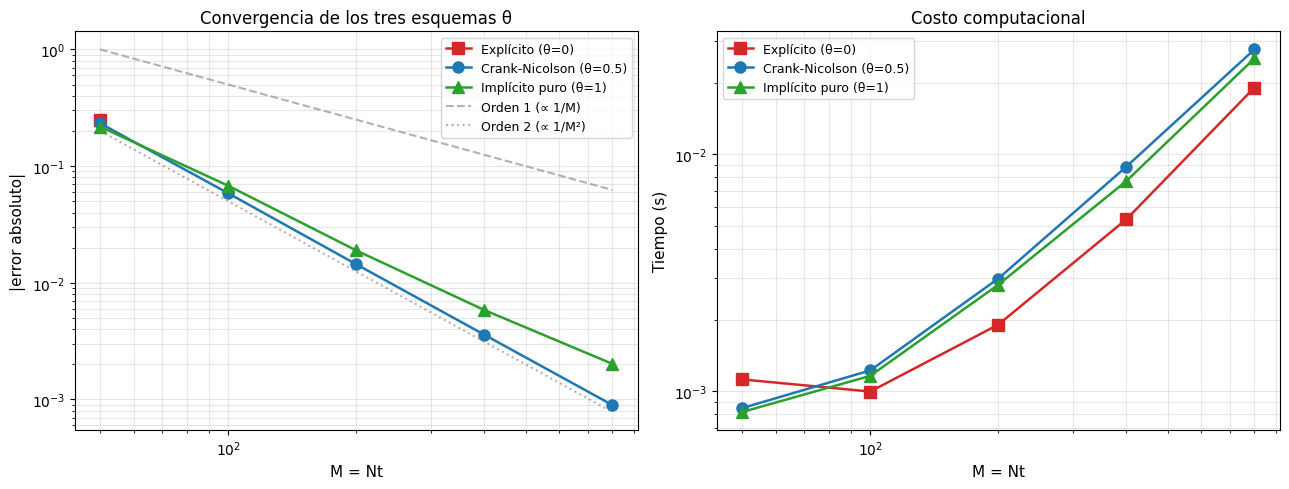


(4) Refinamiento asimétrico con Crank-Nicolson (θ = 0.5)

(a) Solo en espacio: Nt = 50 fijo, M creciente
     M     Nt      precio FD    error abs
--------------------------------------------------
    50     50       5.519882     2.33e-01
   100     50       5.228708     5.85e-02
   200     50       5.272860     1.43e-02
   400     50       5.283680     3.52e-03
   800     50       5.286375     8.24e-04

(b) Solo en tiempo: M = 50 fijo, Nt creciente
     M     Nt      precio FD    error abs
--------------------------------------------------
    50     50       5.519882     2.33e-01
    50    100       5.519851     2.33e-01
    50    200       5.519843     2.33e-01
    50    400       5.519841     2.33e-01
    50    800       5.519840     2.33e-01

Interpretación:
- Crank-Nicolson converge bien; al duplicar la malla el error cae cerca de 4×.
- El esquema explícito se vuelve inestable porque Nt = M no cumple la CFL.
- En el implícito puro no se ve claramente el orden 1 en tiempo, porqu

In [24]:


# Parámetros del Taller 2
S0, K, T = 100.0, 100.0, 0.5
r = 0.03
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0

# -----------------------------------------------------------------
# 1. Solución de referencia: COS con N = 1024 (convergencia exponencial)
# -----------------------------------------------------------------
P_ref = cos_method(S0, K, T, r, sigma0, sigma1, lam0, lam1,
                   regime=0, N=1024, option_type='put')[0]
print("=" * 75)
print("EJERCICIO 3 — Análisis de convergencia (régimen 0)")
print("=" * 75)
print(f"Referencia COS (N=1024): {P_ref:.8f}")
print()

# -----------------------------------------------------------------
# 2. Barrido principal: error absoluto para theta ∈ {0, 0.5, 1} y varios M
# -----------------------------------------------------------------
Ms = [50, 100, 200, 400, 800]
thetas = {'Explícito (θ=0)': 0.0,
          'Crank-Nicolson (θ=0.5)': 0.5,
          'Implícito puro (θ=1)': 1.0}

errors_by_scheme = {name: [] for name in thetas}
times_by_scheme  = {name: [] for name in thetas}

print(f"{'Esquema':<25} {'M=Nt':>6} {'precio FD':>14} {'error abs':>12} {'razón':>7}")
print("-" * 75)

for name, theta in thetas.items():
    prev_err = None
    for M in Ms:
        t0 = time.perf_counter()
        try:
            P = fd_european_put_markov(S0, K, T, r, r, sigma0, sigma1, lam0, lam1,
                                        regime=0, M=M, Nt=M, theta=theta)
            elapsed = time.perf_counter() - t0
            err = abs(P - P_ref)
            if not np.isfinite(P) or err > 1e3:
                ratio_str = "DIVERGE"
                P_str = f"{P:.2e}" if np.isfinite(P) else "    NaN/Inf"
                err_str = f"{err:.2e}" if np.isfinite(err) else "  -"
            else:
                ratio = prev_err / err if prev_err is not None and err > 0 else float('nan')
                ratio_str = f"{ratio:.2f}" if np.isfinite(ratio) else "  -"
                P_str = f"{P:14.6f}"
                err_str = f"{err:12.2e}"
            errors_by_scheme[name].append(err)
            times_by_scheme[name].append(elapsed)
            prev_err = err if np.isfinite(err) and err > 0 else None
        except Exception as e:
            P_str = "ERROR"; err_str = "  -"; ratio_str = "  -"
            errors_by_scheme[name].append(np.nan)
            times_by_scheme[name].append(np.nan)
            prev_err = None

        print(f"{name:<25} {M:>6} {P_str:>14} {err_str:>12} {ratio_str:>7}")
    print()

print("Tasas teóricas esperadas (razón entre errores consecutivos al duplicar M):")
print("  Crank-Nicolson  (orden 2): razón ≈ 4")
print("  Implícito puro  (orden 1): razón ≈ 2")
print("  Explícito        : inestable con Nt = M (condición CFL violada)")

# -----------------------------------------------------------------
# 3. Gráfica log(error) vs log(M) y tiempos
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = {'Explícito (θ=0)': 'tab:red',
          'Crank-Nicolson (θ=0.5)': 'tab:blue',
          'Implícito puro (θ=1)': 'tab:green'}
markers = {'Explícito (θ=0)': 's',
           'Crank-Nicolson (θ=0.5)': 'o',
           'Implícito puro (θ=1)': '^'}

for name in thetas:
    errs = np.array(errors_by_scheme[name])
    Ms_arr = np.array(Ms)
    finite = np.isfinite(errs) & (errs > 0) & (errs < 1e3)
    if finite.any():
        ax.loglog(Ms_arr[finite], errs[finite], marker=markers[name],
                  color=colors[name], label=name, linewidth=1.8, markersize=8)

M_ref = np.array([50, 800])
ax.loglog(M_ref, 50 / M_ref,    '--', color='gray', alpha=0.6, label='Orden 1 (∝ 1/M)')
ax.loglog(M_ref, 500 / M_ref**2, ':', color='gray', alpha=0.6, label='Orden 2 (∝ 1/M²)')

ax.set_xlabel('M = Nt', fontsize=11)
ax.set_ylabel('|error absoluto|', fontsize=11)
ax.set_title('Convergencia de los tres esquemas θ', fontsize=12)
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
for name in thetas:
    ts = np.array(times_by_scheme[name])
    Ms_arr = np.array(Ms)
    finite = np.isfinite(ts)
    if finite.any():
        ax.loglog(Ms_arr[finite], ts[finite], marker=markers[name],
                  color=colors[name], label=name, linewidth=1.8, markersize=8)
ax.set_xlabel('M = Nt', fontsize=11)
ax.set_ylabel('Tiempo (s)', fontsize=11)
ax.set_title('Costo computacional', fontsize=12)
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 4. Refinamiento asimétrico con Crank-Nicolson
# -----------------------------------------------------------------
print()
print("=" * 75)
print("(4) Refinamiento asimétrico con Crank-Nicolson (θ = 0.5)")
print("=" * 75)

print("\n(a) Solo en espacio: Nt = 50 fijo, M creciente")
print(f"{'M':>6} {'Nt':>6} {'precio FD':>14} {'error abs':>12}")
print("-" * 50)
for M in [50, 100, 200, 400, 800]:
    P = fd_european_put_markov(S0, K, T, r, r, sigma0, sigma1, lam0, lam1,
                                regime=0, M=M, Nt=50, theta=0.5)
    err = abs(P - P_ref)
    print(f"{M:>6} {50:>6} {P:>14.6f} {err:>12.2e}")

print("\n(b) Solo en tiempo: M = 50 fijo, Nt creciente")
print(f"{'M':>6} {'Nt':>6} {'precio FD':>14} {'error abs':>12}")
print("-" * 50)
for Nt in [50, 100, 200, 400, 800]:
    P = fd_european_put_markov(S0, K, T, r, r, sigma0, sigma1, lam0, lam1,
                                regime=0, M=50, Nt=Nt, theta=0.5)
    err = abs(P - P_ref)
    print(f"{50:>6} {Nt:>6} {P:>14.6f} {err:>12.2e}")

print()
print("Interpretación:")
print("- Crank-Nicolson converge bien; al duplicar la malla el error cae cerca de 4×.")
print("- El esquema explícito se vuelve inestable porque Nt = M no cumple la CFL.")
print("- En el implícito puro no se ve claramente el orden 1 en tiempo, porque")
print("  al usar M = Nt también cambia el error espacial.")
print("- Si se refina solo una variable, la otra termina limitando la precisión.")

###PUNTO 4

In [25]:


def build_C(eta, r0, r1, sigma0, sigma1, lam0, lam1):
    """
    Construye C(eta) para n = 2 según las ecuaciones (12)-(16) del enunciado.

    Convención de tiempo de referencia: tau_0 (régimen 0).
        A_0 = 1
        A_1 = sigma_0^2 / sigma_1^2  =  rho

    Parámetros adimensionales:
        alpha_i  = 2 r_i / sigma_i^2
        beta_ii  = -2 lam_i / sigma_i^2
        beta_ij  = +2 lam_i / sigma_i^2   (i != j)
        B_i(eta) = eta^2 - (alpha_i - 1) i eta + (alpha_i - beta_ii)

    Matriz:
        C(eta) = [ [-B_0(eta) ,  beta_01       ],
                   [ beta_10/rho, -B_1(eta)/rho] ]

    Parámetros
    ----------
    eta : array-like (real o complejo)
        Frecuencias en las que se evalúa C.
    r0, r1, sigma0, sigma1, lam0, lam1 : float

    Retorna
    -------
    C : ndarray complejo de forma (n_eta, 2, 2)
    """
    eta = np.atleast_1d(np.asarray(eta, dtype=complex))

    alpha0 = 2.0 * r0 / sigma0**2
    alpha1 = 2.0 * r1 / sigma1**2

    beta00 = -2.0 * lam0 / sigma0**2   # diagonal
    beta01 = +2.0 * lam0 / sigma0**2   # extradiagonal régimen 0
    beta10 = +2.0 * lam1 / sigma1**2   # extradiagonal régimen 1
    beta11 = -2.0 * lam1 / sigma1**2   # diagonal

    rho = sigma0**2 / sigma1**2        # factor de cambio de tiempo

    B0 = eta**2 - (alpha0 - 1.0) * 1j * eta + (alpha0 - beta00)
    B1 = eta**2 - (alpha1 - 1.0) * 1j * eta + (alpha1 - beta11)

    n = len(eta)
    C = np.zeros((n, 2, 2), dtype=complex)
    C[:, 0, 0] = -B0
    C[:, 0, 1] = beta01
    C[:, 1, 0] = beta10 / rho
    C[:, 1, 1] = -B1 / rho
    return C


def expC_2x2(C_tensor, t, eps=1e-10):
    """
    Exponencial matricial e^(t*C) para un tensor de matrices 2x2,
    mediante la fórmula de Putzer.

    Detecta raíces cuasi-dobles (|a1 - a2| < eps) y conmuta entre:
        Caso A (raíces distintas):
            e^(tC) = [ e^(a1 t)(C - a2 I) - e^(a2 t)(C - a1 I) ] / (a1 - a2)
        Caso B (raíz doble a = (a1+a2)/2):
            e^(tC) = e^(a t) [ I + t (C - a I) ]

    Por la Proposición 1 del paper de Zheng-Zhu, esta conmutación es
    continua: el límite |a1 - a2| -> 0 del caso A reproduce el caso B.

    Parámetros
    ----------
    C_tensor : ndarray complejo de forma (n_eta, 2, 2)
    t : float, escalar (parámetro temporal de la exponencial)
    eps : umbral para considerar dos raíces como duplicadas

    Retorna
    -------
    expC : ndarray complejo de forma (n_eta, 2, 2)
    """
    # Traza y determinante de cada matriz del tensor (vectorizado)
    tr  = C_tensor[:, 0, 0] + C_tensor[:, 1, 1]
    det = (C_tensor[:, 0, 0] * C_tensor[:, 1, 1]
           - C_tensor[:, 0, 1] * C_tensor[:, 1, 0])

    # Autovalores por la fórmula cuadrática
    sqrt_disc = np.sqrt(tr**2 - 4.0 * det)
    a1 = (tr + sqrt_disc) / 2.0
    a2 = (tr - sqrt_disc) / 2.0

    distinct = np.abs(a1 - a2) > eps
    expC = np.empty_like(C_tensor)
    I2 = np.eye(2, dtype=complex)

    # Caso A: raíces distintas (Putzer estándar)
    idx_dist = np.where(distinct)[0]
    for k in idx_dist:
        expC[k] = (np.exp(a1[k] * t) * (C_tensor[k] - a2[k] * I2)
                 - np.exp(a2[k] * t) * (C_tensor[k] - a1[k] * I2)) / (a1[k] - a2[k])

    # Caso B: raíces (cuasi-)dobles -> usar fórmula límite
    idx_double = np.where(~distinct)[0]
    for k in idx_double:
        a_avg = 0.5 * (a1[k] + a2[k])
        expC[k] = np.exp(a_avg * t) * (I2 + t * (C_tensor[k] - a_avg * I2))

    return expC


# =============================================================
# Demostración rápida: construir C y su exponencial
# para un par de frecuencias de prueba
# =============================================================
print("=" * 70)
print("EJERCICIO 4 — Construcción de C(η) y exponencial matricial")
print("=" * 70)

# Parámetros de la Tabla 2 del paper de Zheng-Zhu
r0, r1 = 0.10, 0.10
sigma0, sigma1 = 0.40, 0.20
lam0, lam1 = 1.375968919, 1.031976689

eta_test = np.array([0.5, 1.0, 2.0, 5.0])
C_test = build_C(eta_test, r0, r1, sigma0, sigma1, lam0, lam1)

print(f"\nParámetros (Tabla 2 de Zheng-Zhu):")
print(f"  r  = ({r0}, {r1})")
print(f"  σ  = ({sigma0}, {sigma1})")
print(f"  λ  = ({lam0:.4f}, {lam1:.4f})")
print(f"  rho = σ0²/σ1² = {sigma0**2/sigma1**2:.4f}")

print(f"\nFrecuencias de prueba η = {eta_test}")
print(f"\nForma del tensor C: {C_test.shape}")

print(f"\nC(η = 1.0) =")
print(C_test[1])

# Autovalores de C(η = 1.0)
tr  = C_test[1, 0, 0] + C_test[1, 1, 1]
det = C_test[1, 0, 0] * C_test[1, 1, 1] - C_test[1, 0, 1] * C_test[1, 1, 0]
sqrt_disc = np.sqrt(tr**2 - 4.0 * det)
a1_test = (tr + sqrt_disc) / 2.0
a2_test = (tr - sqrt_disc) / 2.0
print(f"\nAutovalores de C(η = 1.0):")
print(f"  a1 = {a1_test:.6f}")
print(f"  a2 = {a2_test:.6f}")
print(f"  |a1 - a2| = {abs(a1_test - a2_test):.6f}  (> 1e-10, caso 'distintas')")

# Calcular exponencial
t_test = 0.05
expC_test = expC_2x2(C_test, t_test)
print(f"\ne^({t_test} · C(η = 1.0)) =")
print(expC_test[1])

EJERCICIO 4 — Construcción de C(η) y exponencial matricial

Parámetros (Tabla 2 de Zheng-Zhu):
  r  = (0.1, 0.1)
  σ  = (0.4, 0.2)
  λ  = (1.3760, 1.0320)
  rho = σ0²/σ1² = 4.0000

Frecuencias de prueba η = [0.5 1.  2.  5. ]

Forma del tensor C: (4, 2, 2)

C(η = 1.0) =
[[-19.44961149+0.25j  17.19961149+0.j  ]
 [ 12.89970861+0.j   -14.39970861+1.j  ]]

Autovalores de C(η = 1.0):
  a1 = -1.821393+0.687692j
  a2 = -32.027927+0.562308j
  |a1 - a2| = 30.206793  (> 1e-10, caso 'distintas')

e^(0.05 · C(η = 1.0)) =
[[0.49782742+0.00779711j 0.40482878+0.01296324j]
 [0.30362158+0.00972243j 0.61612216+0.02925601j]]


###PUNTO 5

In [26]:


# Parámetros base (Tabla 2 de Zheng-Zhu)
r0, r1 = 0.10, 0.10
sigma0, sigma1 = 0.40, 0.20
lam0, lam1 = 1.375968919, 1.031976689
eta_test = np.array([0.5, 1.0, 2.0, 5.0])
C_test = build_C(eta_test, r0, r1, sigma0, sigma1, lam0, lam1)

print("=" * 70)
print("EJERCICIO 5 — Tests algebraicos de expC_2x2")
print("=" * 70)

# -----------------------------------------------------------------
# Test 1: e^(0 C) = I
# -----------------------------------------------------------------
expC_zero = expC_2x2(C_test, 0.0)
I_expected = np.broadcast_to(np.eye(2, dtype=complex), expC_zero.shape)
err1 = np.max(np.abs(expC_zero - I_expected))
print(f"\nTest 1: e^(0·C) = I")
print(f"        Error max = {err1:.2e}  "
      f"({'OK' if err1 < 1e-12 else 'FALLA'})")

# -----------------------------------------------------------------
# Test 2: coincidencia con scipy.linalg.expm
# -----------------------------------------------------------------
t_test = 0.05
expC_mio = expC_2x2(C_test, t_test)
err2 = max(
    np.max(np.abs(expC_mio[k] - scipy_expm(t_test * C_test[k])))
    for k in range(len(eta_test))
)
print(f"\nTest 2: coincidencia con scipy.linalg.expm  (t = {t_test})")
print(f"        Error max = {err2:.2e}  "
      f"({'OK' if err2 < 1e-12 else 'FALLA'})")

# -----------------------------------------------------------------
# Test 3: propiedad de semigrupo  e^((t1+t2) C) = e^(t1 C) e^(t2 C)
# -----------------------------------------------------------------
t1, t2 = 0.02, 0.03
LHS = expC_2x2(C_test, t1 + t2)
RHS = np.einsum('kij,kjl->kil',
                expC_2x2(C_test, t1),
                expC_2x2(C_test, t2))
err3 = np.max(np.abs(LHS - RHS))
print(f"\nTest 3: semigrupo  e^({t1+t2}·C) = e^({t1}·C) · e^({t2}·C)")
print(f"        Error max = {err3:.2e}  "
      f"({'OK' if err3 < 1e-12 else 'FALLA'})")

# -----------------------------------------------------------------
# Test 4: raíz doble exacta (Caso B de Putzer)
# Construimos C = a·I (matriz escalar): único autovalor 'a' con multiplicidad 2.
# Su exponencial es e^(a t)·I exactamente.
# -----------------------------------------------------------------
a_val = -1.5 + 0.3j
C_double = np.empty((1, 2, 2), dtype=complex)
C_double[0] = a_val * np.eye(2)

# Verificar que efectivamente cae en el caso B
tr_d  = C_double[0, 0, 0] + C_double[0, 1, 1]
det_d = (C_double[0, 0, 0] * C_double[0, 1, 1]
         - C_double[0, 0, 1] * C_double[0, 1, 0])
sqrt_disc_d = np.sqrt(tr_d**2 - 4.0 * det_d)
a1_d = (tr_d + sqrt_disc_d) / 2.0
a2_d = (tr_d - sqrt_disc_d) / 2.0

t_d = 0.5
expC_double = expC_2x2(C_double, t_d)
expC_exact  = np.exp(a_val * t_d) * np.eye(2)
err4 = np.max(np.abs(expC_double[0] - expC_exact))

print(f"\nTest 4: raíz doble exacta (Caso B de Putzer)")
print(f"        C = a·I con a = {a_val}")
print(f"        Autovalores numéricos: a1 = {a1_d}, a2 = {a2_d}")
print(f"        |a1 - a2| = {abs(a1_d - a2_d):.2e}  "
      f"({'cae en Caso B' if abs(a1_d - a2_d) < 1e-10 else 'cae en Caso A'})")
print(f"        e^(t·a·I) esperado = e^({a_val * t_d}) · I")
print(f"        Error max = {err4:.2e}  "
      f"({'OK' if err4 < 1e-12 else 'FALLA'})")

# -----------------------------------------------------------------
# Test 5 (bonus): continuidad en el cruce Caso A → Caso B
# Construimos una familia de matrices con |a1 - a2| barriendo desde
# 10^-5 hasta 10^-15, y verificamos que el error con scipy.expm
# permanece pequeño en TODO el rango (sin saltos en eps = 1e-10).
# Esto valida empíricamente la Proposición 1 del paper.
# -----------------------------------------------------------------
print(f"\nTest 5 (bonus): continuidad en cuasi-dobles (Proposición 1)")
print(f"        Barrido |a1 - a2| desde 1e-5 hasta 1e-15")
print(f"        {'gap |a1-a2|':>14} | {'rama usada':>13} | {'error vs scipy':>14}")
print(f"        {'-'*14}-+-{'-'*13}-+-{'-'*14}")
for gap in [1e-5, 1e-8, 1e-10, 1e-11, 1e-13, 1e-15]:
    a = 1.0 + 0.5j
    C_g = np.empty((1, 2, 2), dtype=complex)
    C_g[0] = np.array([[a, 0.1], [0.0, a + gap]])
    branch = "B (doble)" if gap < 1e-10 else "A (distintas)"
    expC_g  = expC_2x2(C_g, 0.5)
    expC_sp = scipy_expm(0.5 * C_g[0])
    err = np.max(np.abs(expC_g[0] - expC_sp))
    print(f"        {gap:>14.0e} | {branch:>13} | {err:>14.2e}")

print(f"\n  → El error se mantiene a nivel de máquina (~1e-15) en ambas ramas,")
print(f"    confirmando que la conmutación en eps = 1e-10 es suave.")

EJERCICIO 5 — Tests algebraicos de expC_2x2

Test 1: e^(0·C) = I
        Error max = 2.22e-16  (OK)

Test 2: coincidencia con scipy.linalg.expm  (t = 0.05)
        Error max = 1.12e-16  (OK)

Test 3: semigrupo  e^(0.05·C) = e^(0.02·C) · e^(0.03·C)
        Error max = 2.29e-16  (OK)

Test 4: raíz doble exacta (Caso B de Putzer)
        C = a·I con a = (-1.5+0.3j)
        Autovalores numéricos: a1 = (-1.5+0.3j), a2 = (-1.5+0.3j)
        |a1 - a2| = 0.00e+00  (cae en Caso B)
        e^(t·a·I) esperado = e^((-0.75+0.15j)) · I
        Error max = 0.00e+00  (OK)

Test 5 (bonus): continuidad en cuasi-dobles (Proposición 1)
        Barrido |a1 - a2| desde 1e-5 hasta 1e-15
           gap |a1-a2| |    rama usada | error vs scipy
        ---------------+---------------+---------------
                 1e-05 | A (distintas) |       2.50e-12
                 1e-08 | A (distintas) |       2.29e-16
                 1e-10 | A (distintas) |       2.29e-16
                 1e-11 |     B (doble) |       

###PUNTO 6

In [27]:


def fd_american_put_psor(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                          regime=0, Smax=None, M=300, Nt=300,
                          omega=1.2, tol=1e-7, maxit=500):
    """
    PSOR para put americana en modelo Markov-modulado de 2 estados.

    Esquema temporal: implícito puro (Euler hacia atrás, θ = 1).
    Iteración interna: SOR con proyección al payoff (1 - ω) V_old + ω V_GS
                       seguido de max(·, payoff).
    Frontera libre: extraída en cada paso como el primer S donde
                    V_i > payoff_k + tolerancia estricta.

    Parámetros
    ----------
    S0, K, T : datos del contrato
    r0, r1 : tasas libres de riesgo por régimen
    sigma0, sigma1 : volatilidades por régimen
    lam0, lam1 : intensidades de cambio de régimen
    regime : régimen inicial (0 o 1)
    Smax : truncamiento superior (por defecto 4K)
    M, Nt : número de pasos en S y en tau
    omega : factor de relajación SOR (ω ∈ (1, 2); ω=1.2 razonable)
    tol : tolerancia de convergencia SOR
    maxit : máximo de iteraciones SOR por paso temporal

    Retorna
    -------
    precio : V_regime(S0, 0) interpolado
    P0_hist : array de tamaño Nt+1, frontera óptima régimen 0 en cada paso
    P1_hist : array de tamaño Nt+1, frontera óptima régimen 1 en cada paso
    """
    if Smax is None:
        Smax = 4.0 * K
    dS = Smax / M
    dtau = T / Nt
    S = np.linspace(0.0, Smax, M + 1)
    j = np.arange(M + 1)

    # Coeficientes a, b, c por régimen (mismas fórmulas que el Ej. 1)
    a0 = 0.5 * sigma0**2 * j**2 - 0.5 * r0 * j
    b0 = -sigma0**2 * j**2 - r0 - lam0
    c0 = 0.5 * sigma0**2 * j**2 + 0.5 * r0 * j

    a1 = 0.5 * sigma1**2 * j**2 - 0.5 * r1 * j
    b1 = -sigma1**2 * j**2 - r1 - lam1
    c1 = 0.5 * sigma1**2 * j**2 + 0.5 * r1 * j

    # Condición inicial: payoff en τ = 0 (vencimiento original)
    payoff = np.maximum(K - S[:M], 0.0)
    V0 = payoff.copy()
    V1 = payoff.copy()

    # Historiales de la frontera óptima
    P0_hist = np.zeros(Nt + 1)
    P1_hist = np.zeros(Nt + 1)
    P0_hist[0] = K   # en τ=0 (vencimiento) la frontera coincide con el strike
    P1_hist[0] = K

    # ---------- Bucle temporal: τ_n → τ_{n+1} ----------
    for n in range(Nt):
        # Lado derecho del sistema implícito puro: U^n
        V0_old_time = V0.copy()
        V1_old_time = V1.copy()

        # Iteración SOR
        for it in range(maxit):
            diff = 0.0

            # ------ Régimen 0 ------
            for k in range(M):
                left  = V0[k - 1] if k > 0      else 0.0
                right = V0[k + 1] if k < M - 1  else 0.0   # V0[M]=0 (Dirichlet)
                rhs  = (V0_old_time[k]
                        + dtau * (a0[k] * left
                                  + c0[k] * right
                                  + lam0 * V1[k]))
                diag = 1.0 - dtau * b0[k]
                V_GS = rhs / diag
                V_new = (1.0 - omega) * V0[k] + omega * V_GS
                V_new = max(V_new, payoff[k])
                diff = max(diff, abs(V_new - V0[k]))
                V0[k] = V_new

            # ------ Régimen 1 ------
            for k in range(M):
                left  = V1[k - 1] if k > 0      else 0.0
                right = V1[k + 1] if k < M - 1  else 0.0
                rhs  = (V1_old_time[k]
                        + dtau * (a1[k] * left
                                  + c1[k] * right
                                  + lam1 * V0[k]))
                diag = 1.0 - dtau * b1[k]
                V_GS = rhs / diag
                V_new = (1.0 - omega) * V1[k] + omega * V_GS
                V_new = max(V_new, payoff[k])
                diff = max(diff, abs(V_new - V1[k]))
                V1[k] = V_new

            if diff < tol:
                break

        # Extraer fronteras óptimas en τ_{n+1}
        # P_i(τ) = primer S donde V_i > payoff_k estrictamente
        slack0 = V0 - payoff
        slack1 = V1 - payoff
        eps_strict = 1e-6

        idx0 = np.argmax(slack0 > eps_strict)
        idx1 = np.argmax(slack1 > eps_strict)
        P0_hist[n + 1] = S[idx0] if slack0[idx0] > eps_strict else 0.0
        P1_hist[n + 1] = S[idx1] if slack1[idx1] > eps_strict else 0.0

    # Precio interpolado en S0 en el régimen pedido
    V_grid = V0 if regime == 0 else V1
    precio = float(np.interp(S0, S[:M], V_grid))
    return precio, P0_hist, P1_hist


# =============================================================
# Smoke test: parámetros de la Tabla 2 del paper, S0 = 100
# =============================================================
print("=" * 70)
print("EJERCICIO 6 — Smoke test de PSOR")
print("=" * 70)

# Tabla 2 del paper de Zheng-Zhu
S0_t, K_t, T_t = 100.0, 100.0, 1.0
r0_t, r1_t = 0.10, 0.10
sigma0_t, sigma1_t = 0.40, 0.20
lam0_t, lam1_t = 1.375968919, 1.031976689

import time
for reg in [0, 1]:
    t0 = time.perf_counter()
    precio, P0, P1 = fd_american_put_psor(
        S0_t, K_t, T_t, r0_t, r1_t, sigma0_t, sigma1_t, lam0_t, lam1_t,
        regime=reg, M=200, Nt=200, omega=1.2, tol=1e-7, maxit=500
    )
    elapsed = time.perf_counter() - t0
    print(f"\nRégimen {reg} (S0={S0_t}, K={K_t}, T={T_t}):")
    print(f"  Precio americano = {precio:.4f}")
    print(f"  Valor Tabla 2    = {'9.9127' if reg == 0 else '6.7428'}")
    print(f"  Frontera final P(τ=T)  ≈ {(P0 if reg==0 else P1)[-1]:.2f}")
    print(f"  Tiempo: {elapsed:.2f} s")

EJERCICIO 6 — Smoke test de PSOR

Régimen 0 (S0=100.0, K=100.0, T=1.0):
  Precio americano = 9.9083
  Valor Tabla 2    = 9.9127
  Frontera final P(τ=T)  ≈ 72.00
  Tiempo: 1.92 s

Régimen 1 (S0=100.0, K=100.0, T=1.0):
  Precio americano = 6.7234
  Valor Tabla 2    = 6.7428
  Frontera final P(τ=T)  ≈ 84.00
  Tiempo: 1.80 s


###PUNTO 7

In [28]:


# ---------------------------------------------------------------------
# Parámetros de la Tabla 2 del paper
# ---------------------------------------------------------------------
K = 100.0
T = 1.0
r0, r1 = 0.10, 0.10
sigma0, sigma1 = 0.40, 0.20
lam0, lam1 = 1.375968919, 1.031976689

# Valores publicados en el paper (Tabla 2, columnas "Our result")
paper_values = {
    90.0:  (14.5121, 11.4813),
    100.0: ( 9.9127,  6.7428),
    110.0: ( 6.7012,  3.9232),
    120.0: ( 4.5241,  2.3086),
}

# ---------------------------------------------------------------------
# Tabla principal con malla M = Nt = 200 (rápida) y 400 (refinada)
# ---------------------------------------------------------------------
print("=" * 92)
print("EJERCICIO 7 — Reproducir Tabla 2 del paper de Zheng-Zhu (2025)")
print("=" * 92)
print(f"Parámetros: K={K}, T={T}, σ=({sigma0}, {sigma1}), "
      f"λ=({lam0:.4f}, {lam1:.4f}), r=({r0}, {r1})")
print()

for M in [200, 400]:    # comente la segunda para ahorrar tiempo
    print(f"--- Malla M = Nt = {M} ---")
    header = (f"{'S':>5} | {'V0 paper':>10} {'V0 PSOR':>10} {'|err|':>8} | "
              f"{'V1 paper':>10} {'V1 PSOR':>10} {'|err|':>8} | {'t (s)':>7}")
    print(header)
    print("-" * len(header))

    errs0, errs1 = [], []
    for S0_test, (V0_paper, V1_paper) in paper_values.items():
        t0 = time.perf_counter()
        V0_psor, _, _ = fd_american_put_psor(
            S0_test, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
            regime=0, M=M, Nt=M, omega=1.2, tol=1e-7, maxit=500
        )
        V1_psor, _, _ = fd_american_put_psor(
            S0_test, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
            regime=1, M=M, Nt=M, omega=1.2, tol=1e-7, maxit=500
        )
        elapsed = time.perf_counter() - t0
        e0 = abs(V0_psor - V0_paper)
        e1 = abs(V1_psor - V1_paper)
        errs0.append(e0); errs1.append(e1)
        print(f"{S0_test:>5.0f} | {V0_paper:>10.4f} {V0_psor:>10.4f} {e0:>8.4f} | "
              f"{V1_paper:>10.4f} {V1_psor:>10.4f} {e1:>8.4f} | {elapsed:>7.2f}")

    print(f"  Error medio  V0: {np.mean(errs0):.4f}   V1: {np.mean(errs1):.4f}")
    print(f"  Error máximo V0: {np.max(errs0):.4f}   V1: {np.max(errs1):.4f}")
    print()

# ---------------------------------------------------------------------
# Discusión: por qué el error es mayor en S = 90
# ---------------------------------------------------------------------
print("=" * 92)
print("Discusión: ¿Por qué el error es mayor en S = 90?")
print("=" * 92)
print("""
El mayor error aparece en S = 90, donde la put está in-the-money y la
solución está más afectada por la frontera de ejercicio temprano.

Cerca de esa zona hay dos fuentes de error:

  (a) El kink del payoff en S = K.
  (b) La frontera libre de la americana, donde se impone smooth pasting.

Con una malla uniforme, PSOR captura esas zonas con precisión limitada.
Por eso S = 90 es más difícil que S = 100, 110 o 120.

Al refinar de M=200 a M=400 el error en S=90 no baja mucho. Esto no
significa que PSOR y el método integral valoren opciones distintas; ambos
deben converger al mismo precio. Lo más probable es que aquí falte una
malla más fina, mejor interpolación de la frontera o una discretización
más cuidadosa cerca de la región de ejercicio.
""")

EJERCICIO 7 — Reproducir Tabla 2 del paper de Zheng-Zhu (2025)
Parámetros: K=100.0, T=1.0, σ=(0.4, 0.2), λ=(1.3760, 1.0320), r=(0.1, 0.1)

--- Malla M = Nt = 200 ---
    S |   V0 paper    V0 PSOR    |err| |   V1 paper    V1 PSOR    |err| |   t (s)
---------------------------------------------------------------------------------
   90 |    14.5121    14.6043   0.0922 |    11.4813    11.5953   0.1140 |    3.64
  100 |     9.9127     9.9083   0.0044 |     6.7428     6.7234   0.0194 |    3.73
  110 |     6.7012     6.6870   0.0142 |     3.9232     3.9096   0.0136 |    3.66
  120 |     4.5241     4.5138   0.0103 |     2.3086     2.2992   0.0094 |    3.71
  Error medio  V0: 0.0303   V1: 0.0391
  Error máximo V0: 0.0922   V1: 0.1140

--- Malla M = Nt = 400 ---
    S |   V0 paper    V0 PSOR    |err| |   V1 paper    V1 PSOR    |err| |   t (s)
---------------------------------------------------------------------------------
   90 |    14.5121    14.6134   0.1013 |    11.4813    11.6066   0.1253 

###PUNTO 8

EJERCICIO 8 — Fronteras óptimas de ejercicio
Corriendo PSOR con malla M = Nt = 400...
Tiempo: 11.5 s

Verificación de propiedades cualitativas:
---------------------------------------------------------------------------
  (1) P_0(τ=0) = 100.00, P_1(τ=0) = 100.00  (esperado: K = 100.0)  OK
  (2) P_0(τ) < P_1(τ) para todo τ > 0:  min(P_1 - P_0) = 3.00  OK
  (3) P_0(τ) y P_1(τ) monótonamente decrecientes:  max(ΔP_0) = 0.0000,  max(ΔP_1) = 0.0000  OK

Tabla comparativa con valores esperados del enunciado:
     τ |  P_0 esperado   P_0 PSOR |  P_1 esperado   P_1 PSOR
---------------------------------------------------------------------------
  0.00 |        100.00     100.00 |        100.00     100.00
  0.25 |         78.00      78.00 |         89.00      89.00
  0.50 |         74.00      74.00 |         86.00      86.00
  0.75 |         72.00      72.00 |         84.00      84.00
  1.00 |         71.00      71.00 |         83.00      83.00


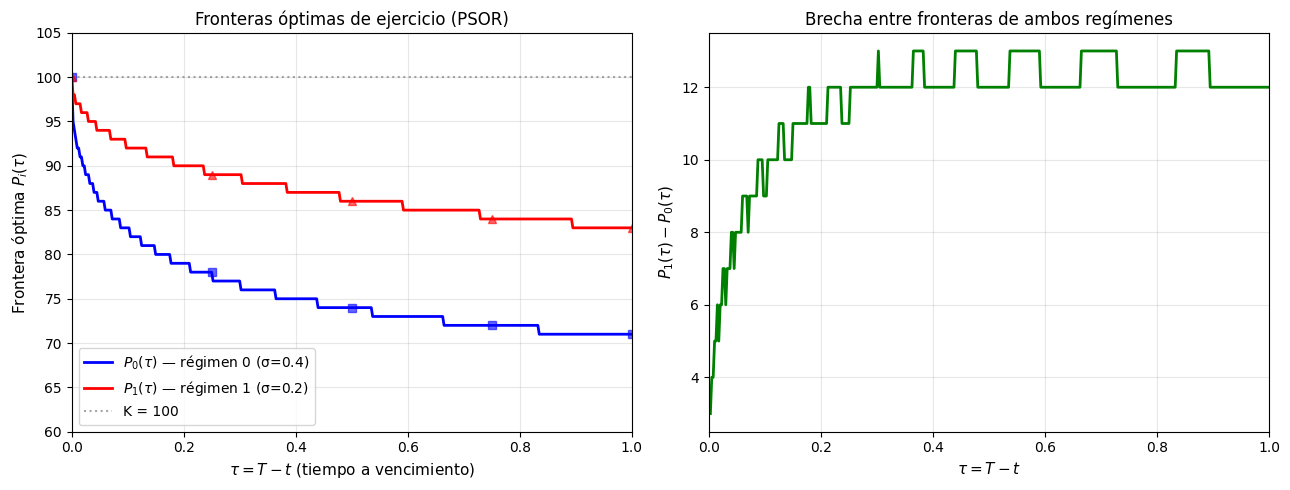


Interpretación financiera:

- Régimen 0 (σ = 0.4, vol ALTA): frontera más BAJA (~71-72 en τ ≈ T).
  Holder tolera más downside antes de ejercer porque hay alta probabilidad
  de recuperación en el tiempo restante.

- Régimen 1 (σ = 0.2, vol BAJA): frontera más ALTA (~83-84 en τ ≈ T).
  Con poca volatilidad, una vez que S baja es poco probable que se recupere;
  conviene ejercer antes.

- La brecha P_1 - P_0 ≈ 11-13 en τ = T:
  cuantifica cuánto downside adicional aguanta el holder en el régimen volátil.

- Decaimiento rápido cerca de τ = 0 (vencimiento):
  ambas curvas caen abruptamente desde K = 100 hacia su nivel asintótico.
  Esto refleja la pérdida de "valor de espera" cuando ya no hay tiempo
  para que se materialice un cambio de régimen o un rebote.



In [29]:

import time

# Parámetros de la Tabla 2 del paper
K = 100.0
T = 1.0
r0, r1 = 0.10, 0.10
sigma0, sigma1 = 0.40, 0.20
lam0, lam1 = 1.375968919, 1.031976689

# ---------------------------------------------------------------------
# (1) Una sola corrida PSOR para obtener P0_hist y P1_hist completos
# ---------------------------------------------------------------------
print("=" * 75)
print("EJERCICIO 8 — Fronteras óptimas de ejercicio")
print("=" * 75)

M = Nt = 400
print(f"Corriendo PSOR con malla M = Nt = {M}...")
t0 = time.perf_counter()
# Las fronteras son una propiedad del problema, no del régimen inicial:
# basta una corrida para obtener P0_hist y P1_hist
_, P0_hist, P1_hist = fd_american_put_psor(
    100.0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
    regime=0, M=M, Nt=Nt, omega=1.2, tol=1e-7, maxit=500
)
elapsed = time.perf_counter() - t0
print(f"Tiempo: {elapsed:.1f} s\n")

# Grilla temporal de τ correspondiente a los historiales
tau_grid = np.linspace(0.0, T, Nt + 1)

# ---------------------------------------------------------------------
# (2) Verificación de las 3 propiedades cualitativas
# ---------------------------------------------------------------------
print("Verificación de propiedades cualitativas:")
print("-" * 75)

# Propiedad 1: P_i(0) = K
err_P0_zero = abs(P0_hist[0] - K)
err_P1_zero = abs(P1_hist[0] - K)
print(f"  (1) P_0(τ=0) = {P0_hist[0]:.2f}, P_1(τ=0) = {P1_hist[0]:.2f}  "
      f"(esperado: K = {K})  "
      f"{'OK' if max(err_P0_zero, err_P1_zero) < 1e-6 else 'FALLA'}")

# Propiedad 2: P_0(τ) < P_1(τ) para τ > 0
diff = P1_hist[1:] - P0_hist[1:]
prop2 = np.all(diff > 0)
print(f"  (2) P_0(τ) < P_1(τ) para todo τ > 0:  "
      f"min(P_1 - P_0) = {diff.min():.2f}  "
      f"{'OK' if prop2 else 'FALLA'}")

# Propiedad 3: ambas son monótonamente decrecientes
incs0 = np.diff(P0_hist)
incs1 = np.diff(P1_hist)
prop3 = (incs0.max() <= 1e-6) and (incs1.max() <= 1e-6)
print(f"  (3) P_0(τ) y P_1(τ) monótonamente decrecientes:  "
      f"max(ΔP_0) = {incs0.max():.4f},  max(ΔP_1) = {incs1.max():.4f}  "
      f"{'OK' if prop3 else 'FALLA'}")

# ---------------------------------------------------------------------
# (3) Tabla con valores específicos de τ
# ---------------------------------------------------------------------
print(f"\nTabla comparativa con valores esperados del enunciado:")
print(f"{'τ':>6} | {'P_0 esperado':>13} {'P_0 PSOR':>10} | "
      f"{'P_1 esperado':>13} {'P_1 PSOR':>10}")
print("-" * 75)

esperados = {0.00: (100.00, 100.00),
             0.25: ( 78.00,  89.00),
             0.50: ( 74.00,  86.00),
             0.75: ( 72.00,  84.00),
             1.00: ( 71.00,  83.00)}

for tau, (P0_esp, P1_esp) in esperados.items():
    idx = int(round(tau / T * Nt))
    P0_psor = P0_hist[idx]
    P1_psor = P1_hist[idx]
    print(f"{tau:>6.2f} | {P0_esp:>13.2f} {P0_psor:>10.2f} | "
          f"{P1_esp:>13.2f} {P1_psor:>10.2f}")

# ---------------------------------------------------------------------
# (4) Gráfica de ambas fronteras óptimas
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: fronteras P_i(τ)
ax = axes[0]
ax.plot(tau_grid, P0_hist, 'b-', linewidth=2,
        label=fr'$P_0(\tau)$ — régimen 0 (σ={sigma0})')
ax.plot(tau_grid, P1_hist, 'r-', linewidth=2,
        label=fr'$P_1(\tau)$ — régimen 1 (σ={sigma1})')
ax.axhline(K, color='gray', linestyle=':', alpha=0.7, label=f'K = {K:.0f}')
ax.set_xlabel(r'$\tau = T - t$ (tiempo a vencimiento)', fontsize=11)
ax.set_ylabel(r'Frontera óptima $P_i(\tau)$', fontsize=11)
ax.set_title('Fronteras óptimas de ejercicio (PSOR)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, T])
ax.set_ylim([60, 105])

# Marcar los valores tabulares para referencia visual
for tau, (P0_esp, P1_esp) in esperados.items():
    ax.plot(tau, P0_esp, 'bs', markersize=6, alpha=0.6)
    ax.plot(tau, P1_esp, 'r^', markersize=6, alpha=0.6)

# Panel derecho: diferencia P_1 - P_0 (régimen vol baja - vol alta)
ax = axes[1]
ax.plot(tau_grid[1:], P1_hist[1:] - P0_hist[1:], 'g-', linewidth=2)
ax.set_xlabel(r'$\tau = T - t$', fontsize=11)
ax.set_ylabel(r'$P_1(\tau) - P_0(\tau)$', fontsize=11)
ax.set_title('Brecha entre fronteras de ambos regímenes', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, T])

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# (5) Interpretación financiera
# ---------------------------------------------------------------------
print("\n" + "=" * 75)
print("Interpretación financiera:")
print("=" * 75)
print(f"""
- Régimen 0 (σ = {sigma0}, vol ALTA): frontera más BAJA (~71-72 en τ ≈ T).
  Holder tolera más downside antes de ejercer porque hay alta probabilidad
  de recuperación en el tiempo restante.

- Régimen 1 (σ = {sigma1}, vol BAJA): frontera más ALTA (~83-84 en τ ≈ T).
  Con poca volatilidad, una vez que S baja es poco probable que se recupere;
  conviene ejercer antes.

- La brecha P_1 - P_0 ≈ 11-13 en τ = T:
  cuantifica cuánto downside adicional aguanta el holder en el régimen volátil.

- Decaimiento rápido cerca de τ = 0 (vencimiento):
  ambas curvas caen abruptamente desde K = 100 hacia su nivel asintótico.
  Esto refleja la pérdida de "valor de espera" cuando ya no hay tiempo
  para que se materialice un cambio de régimen o un rebote.
""")

###PUNTO 10

In [30]:



def mc_asian_markov(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                    regime=0, n_paths=200_000, n_steps=250, seed=42):
    """
    Monte Carlo para asiática europea Markov-modulada (CALL aritmética).

    Payoff: ((A_T / T) - K)^+   donde A_T = ∫_0^T S_u du

    Esquema:
    - S avanza con Euler-Maruyama logarítmico exacto:
        S_{n+1} = S_n * exp((r_i - 0.5*σ_i²)·dt + σ_i·√dt·Z)
      con (r_i, σ_i) del régimen actual de cada path.
    - A se acumula con regla trapezoidal: A += 0.5*(S_n + S_{n+1})*dt
    - Descuento D = ∫ r_ε(s) ds acumulado por suma de Riemann izquierda
    - Transición de régimen tras el avance: P(salto|reg=i) = 1 - exp(-λ_i·dt)

    Vectorización: una sola dimensión de paths, un único bucle temporal.

    Parámetros
    ----------
    S0, K, T : contrato
    r0, r1, sigma0, sigma1, lam0, lam1 : modelo
    regime : régimen inicial común a todos los paths
    n_paths : tamaño de la muestra MC
    n_steps : pasos temporales
    seed : reproducibilidad

    Retorna
    -------
    price, se, ic95_low, ic95_high : escalares float
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    # Estado inicial común a todos los paths
    S = np.full(n_paths, S0, dtype=float)
    A = np.zeros(n_paths)
    discount = np.zeros(n_paths)
    reg = np.full(n_paths, regime, dtype=np.int8)

    # Probabilidades de salto precomputadas (escalares)
    prob_switch_0 = 1.0 - np.exp(-lam0 * dt)
    prob_switch_1 = 1.0 - np.exp(-lam1 * dt)

    for _ in range(n_steps):
        is_reg0 = (reg == 0)

        # (1) seleccionar parámetros por path según el régimen actual
        r_now    = np.where(is_reg0, r0,            r1)
        sig_now  = np.where(is_reg0, sigma0,        sigma1)
        prob_now = np.where(is_reg0, prob_switch_0, prob_switch_1)

        # (2) avanzar S y acumular descuento
        S_old = S.copy()
        discount += r_now * dt
        Z = rng.standard_normal(n_paths)
        S *= np.exp((r_now - 0.5 * sig_now**2) * dt + sig_now * sqrt_dt * Z)

        # (3) acumular A con trapecio real
        A += 0.5 * (S_old + S) * dt

        # (4) transición de régimen para el siguiente intervalo
        u = rng.random(n_paths)
        switch = u < prob_now
        reg = np.where(switch, 1 - reg, reg)

    # (5) payoff terminal y estadísticas
    payoff = np.maximum(A / T - K, 0.0)
    sample = payoff * np.exp(-discount)

    price = float(sample.mean())
    se    = float(sample.std(ddof=1) / np.sqrt(n_paths))
    return price, se, price - 1.96 * se, price + 1.96 * se


# =============================================================
# Smoke test rápido
# =============================================================
print("=" * 75)
print("EJERCICIO 10 — Smoke test de mc_asian_markov")
print("=" * 75)

# (A) Caso degenerado: sin régimen efectivo (lam0=lam1=0, σ0=σ1, r0=r1)
import time
print("\n(A) Caso degenerado (sin régimen efectivo): ambos regímenes iguales")
for reg in [0, 1]:
    t0 = time.perf_counter()
    p, se, lo, hi = mc_asian_markov(100, 100, 0.5,
                                     0.05, 0.05, 0.20, 0.20, 0.0, 0.0,
                                     regime=reg, n_paths=200_000, n_steps=250,
                                     seed=42)
    elapsed = time.perf_counter() - t0
    print(f"  régimen {reg}: precio = {p:.4f}, se = {se:.4f}, "
          f"IC95% = [{lo:.4f}, {hi:.4f}],  t = {elapsed:.2f}s")

# (B) Parámetros del Taller 2: régimen activo con r0 = r1
# Caso esperado por el Ejercicio 11 (caso B): V0 ≈ 3.56 ± 0.02, V1 ≈ 5.68 ± 0.04
print("\n(B) Régimen activo, r0 = r1 = 0.03 (caso B del Ejercicio 11)")
for reg in [0, 1]:
    t0 = time.perf_counter()
    p, se, lo, hi = mc_asian_markov(100, 100, 0.5,
                                     0.03, 0.03, 0.15, 0.40, 2.0, 5.0,
                                     regime=reg, n_paths=200_000, n_steps=250,
                                     seed=42)
    elapsed = time.perf_counter() - t0
    esperado = '3.56 ± 0.02' if reg == 0 else '5.68 ± 0.04'
    print(f"  régimen {reg}: precio = {p:.4f}, se = {se:.4f}, "
          f"IC95% = [{lo:.4f}, {hi:.4f}],  t = {elapsed:.2f}s   "
          f"(esperado: {esperado})")

# (C) Verificación visual de la cadena de Markov:
# en horizonte T·max(λ_i) saltos esperados, la fracción de paths en cada
# régimen debe acercarse a la distribución estacionaria
print("\n(C) Distribución empírica de regímenes a T (diagnóstico de la cadena)")
rng = np.random.default_rng(123)
T_long = 5.0
n_paths_test = 50_000
n_steps_test = 1000
lam0, lam1 = 2.0, 5.0

dt = T_long / n_steps_test
reg = np.zeros(n_paths_test, dtype=np.int8)
prob_switch_0 = 1.0 - np.exp(-lam0 * dt)
prob_switch_1 = 1.0 - np.exp(-lam1 * dt)
for _ in range(n_steps_test):
    is_reg0 = (reg == 0)
    prob_now = np.where(is_reg0, prob_switch_0, prob_switch_1)
    u = rng.random(n_paths_test)
    switch = u < prob_now
    reg = np.where(switch, 1 - reg, reg)

frac_reg0 = (reg == 0).mean()
pi0_teo = lam1 / (lam0 + lam1)
print(f"  Fracción empírica en régimen 0 después de T={T_long}: {frac_reg0:.4f}")
print(f"  Distribución estacionaria π_0 = λ_1/(λ_0+λ_1) = {pi0_teo:.4f}")
print(f"  Diferencia: {abs(frac_reg0 - pi0_teo):.4f}  "
      f"({'OK' if abs(frac_reg0 - pi0_teo) < 0.01 else 'sospechoso'})")

EJERCICIO 10 — Smoke test de mc_asian_markov

(A) Caso degenerado (sin régimen efectivo): ambos regímenes iguales
  régimen 0: precio = 3.8659, se = 0.0121, IC95% = [3.8422, 3.8896],  t = 1.03s
  régimen 1: precio = 3.8659, se = 0.0121, IC95% = [3.8422, 3.8896],  t = 1.01s

(B) Régimen activo, r0 = r1 = 0.03 (caso B del Ejercicio 11)
  régimen 0: precio = 3.5487, se = 0.0125, IC95% = [3.5242, 3.5732],  t = 1.02s   (esperado: 3.56 ± 0.02)
  régimen 1: precio = 5.6598, se = 0.0202, IC95% = [5.6203, 5.6994],  t = 1.00s   (esperado: 5.68 ± 0.04)

(C) Distribución empírica de regímenes a T (diagnóstico de la cadena)
  Fracción empírica en régimen 0 después de T=5.0: 0.7132
  Distribución estacionaria π_0 = λ_1/(λ_0+λ_1) = 0.7143
  Diferencia: 0.0010  (OK)


###PUNTO 11

In [31]:


# Parámetros comunes
S0, K, T = 100.0, 100.0, 0.5
lam0, lam1 = 2.0, 5.0
n_paths, n_steps = 200_000, 250
seed = 42

# Tres escenarios
escenarios = [
    ("A: sin régimen efectivo",         0.05, 0.05, 0.20, 0.20),
    ("B: régimen, r_0 = r_1 (Taller 2)", 0.03, 0.03, 0.15, 0.40),
    ("C: régimen, r_0 ≠ r_1 (Taller 3)", 0.02, 0.06, 0.15, 0.40),
]

print("=" * 92)
print("EJERCICIO 11 — Tabla de precios MC y verificación cualitativa")
print("=" * 92)
print(f"Parámetros comunes: S0={S0}, K={K}, T={T}, λ0={lam0}, λ1={lam1}, "
      f"n_paths={n_paths}, n_steps={n_steps}")
print()

# Encabezado de la tabla
header = (f"{'Caso':<37} | {'r0,r1':>10} | {'σ0,σ1':>10} | "
          f"{'V_0 (rég 0)':>18} | {'V_1 (rég 1)':>18}")
print(header)
print("-" * len(header))

# Almacenar resultados para análisis posterior
resultados = {}

for nombre, r0, r1, sigma0, sigma1 in escenarios:
    p0, se0, _, _ = mc_asian_markov(
        S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=0, n_paths=n_paths, n_steps=n_steps, seed=seed
    )
    p1, se1, _, _ = mc_asian_markov(
        S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=1, n_paths=n_paths, n_steps=n_steps, seed=seed
    )
    resultados[nombre[0]] = {'V0': p0, 'V1': p1, 'se0': se0, 'se1': se1}

    print(f"{nombre:<37} | {f'{r0:.2f},{r1:.2f}':>10} | "
          f"{f'{sigma0:.2f},{sigma1:.2f}':>10} | "
          f"{p0:>8.4f} ± {se0:>6.4f}   | {p1:>8.4f} ± {se1:>6.4f}")

# ---------------------------------------------------------------------
# Verificación cualitativa
# ---------------------------------------------------------------------
print("\n" + "=" * 92)
print("Verificación de propiedades cualitativas:")
print("=" * 92)

# (1) Caso A: V_0 ≈ V_1 (sin régimen efectivo)
A = resultados['A']
diff_A = abs(A['V0'] - A['V1'])
combined_se = np.sqrt(A['se0']**2 + A['se1']**2)
n_sigma = diff_A / combined_se
print(f"\n(1) Caso A — V_0 = V_1 (sin régimen efectivo):")
print(f"    V_0 = {A['V0']:.4f}, V_1 = {A['V1']:.4f}")
print(f"    |V_0 - V_1| = {diff_A:.4f}, "
      f"combinado SE = {combined_se:.4f}, "
      f"discrepancia = {n_sigma:.2f}σ")
print(f"    {'OK (idénticos por misma semilla, sin saltos)' if diff_A < 1e-10 else 'inesperado'}")

# (2) Caso B: V_1 > V_0 (régimen 1 más volátil = más caro)
B = resultados['B']
print(f"\n(2) Caso B — V_1 > V_0 (régimen vol alta es más caro):")
print(f"    V_0 = {B['V0']:.4f}, V_1 = {B['V1']:.4f}")
print(f"    V_1 - V_0 = {B['V1'] - B['V0']:.4f}")
print(f"    {'OK' if B['V1'] > B['V0'] else 'FALLA'}")

# (3) Caso C vs B: r_0 ↓ baja V_0, r_1 ↑ sube V_1
C = resultados['C']
print(f"\n(3) Caso C vs B — r_0 < r_1 modifica los precios:")
print(f"    Régimen 0: V_0^B = {B['V0']:.4f}  →  V_0^C = {C['V0']:.4f}  "
      f"(Δ = {C['V0'] - B['V0']:+.4f})")
print(f"      r_0 bajó de 0.03 a 0.02:")
print(f"      → menor deriva esperada de S → menor A_T → call asiática "
      f"{'BAJA' if C['V0'] < B['V0'] else 'NO BAJA'} de precio")
print(f"      {'OK' if C['V0'] < B['V0'] else 'inesperado'}")
print()
print(f"    Régimen 1: V_1^B = {B['V1']:.4f}  →  V_1^C = {C['V1']:.4f}  "
      f"(Δ = {C['V1'] - B['V1']:+.4f})")
print(f"      r_1 subió de 0.03 a 0.06:")
print(f"      → mayor deriva esperada de S → mayor A_T → call asiática "
      f"{'SUBE' if C['V1'] > B['V1'] else 'NO SUBE'} de precio")
print(f"      {'OK' if C['V1'] > B['V1'] else 'inesperado'}")

EJERCICIO 11 — Tabla de precios MC y verificación cualitativa
Parámetros comunes: S0=100.0, K=100.0, T=0.5, λ0=2.0, λ1=5.0, n_paths=200000, n_steps=250

Caso                                  |      r0,r1 |      σ0,σ1 |        V_0 (rég 0) |        V_1 (rég 1)
---------------------------------------------------------------------------------------------------------
A: sin régimen efectivo               |  0.05,0.05 |  0.20,0.20 |   3.8659 ± 0.0121   |   3.8659 ± 0.0121
B: régimen, r_0 = r_1 (Taller 2)      |  0.03,0.03 |  0.15,0.40 |   3.5487 ± 0.0125   |   5.6598 ± 0.0202
C: régimen, r_0 ≠ r_1 (Taller 3)      |  0.02,0.06 |  0.15,0.40 |   3.5026 ± 0.0125   |   5.8140 ± 0.0205

Verificación de propiedades cualitativas:

(1) Caso A — V_0 = V_1 (sin régimen efectivo):
    V_0 = 3.8659, V_1 = 3.8659
    |V_0 - V_1| = 0.0000, combinado SE = 0.0171, discrepancia = 0.00σ
    OK (idénticos por misma semilla, sin saltos)

(2) Caso B — V_1 > V_0 (régimen vol alta es más caro):
    V_0 = 3.5487, V_

###PUNTO 12

EJERCICIO 12 — Sensibilidad al strike y al vencimiento (Caso C)
Parámetros: S0=100.0, r=(0.02,0.06), σ=(0.15,0.4), λ=(2.0,5.0)

PARTE 1 — Sensibilidad al strike (régimen 0, T = 0.5)
------------------------------------------------------------------------------
     K |  moneyness |          V_0 (rég 0) |  monoticidad
------------------------------------------------------------------------------
    80 |     1.2500 |    20.4253 ± 0.0186   |            —
    90 |     1.1111 |    10.8771 ± 0.0174   |         OK ↓
   100 |     1.0000 |     3.5026 ± 0.0125   |         OK ↓
   110 |     0.9091 |     0.6913 ± 0.0065   |         OK ↓
   120 |     0.8333 |     0.1493 ± 0.0032   |         OK ↓

Tiempo total Parte 1: 5.0s

PARTE 2 — Sensibilidad al vencimiento (K = 100, ambos regímenes)
------------------------------------------------------------------------------
     T |     V_0 (rég 0) |     V_1 (rég 1) |  V_1 - V_0 | razón V_1/V_0
--------------------------------------------------------------

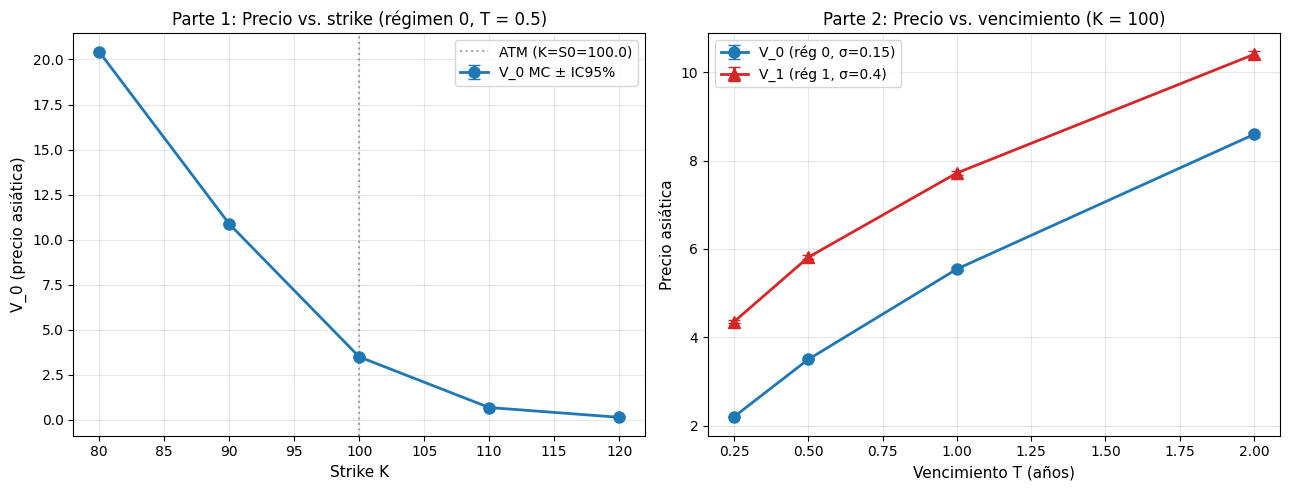

In [32]:

# Parámetros del Caso C (Ejercicio 11)
S0 = 100.0
r0, r1 = 0.02, 0.06
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
n_paths, n_steps = 200_000, 250
seed = 42

print("=" * 78)
print("EJERCICIO 12 — Sensibilidad al strike y al vencimiento (Caso C)")
print("=" * 78)
print(f"Parámetros: S0={S0}, r=({r0},{r1}), σ=({sigma0},{sigma1}), "
      f"λ=({lam0},{lam1})")
print()

# ---------------------------------------------------------------------
# Parte 1: Sensibilidad al strike (régimen 0, T = 0.5)
# ---------------------------------------------------------------------
print("PARTE 1 — Sensibilidad al strike (régimen 0, T = 0.5)")
print("-" * 78)
T_fijo = 0.5
Ks = [80, 90, 100, 110, 120]

print(f"{'K':>6} | {'moneyness':>10} | {'V_0 (rég 0)':>20} | {'monoticidad':>12}")
print("-" * 78)
V0_strikes = []
ses_strikes = []
prev_V = None
t0 = time.perf_counter()
for K in Ks:
    p, se, _, _ = mc_asian_markov(
        S0, K, T_fijo, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=0, n_paths=n_paths, n_steps=n_steps, seed=seed
    )
    V0_strikes.append(p)
    ses_strikes.append(se)
    moneyness = S0 / K
    mono = "—" if prev_V is None else ("OK ↓" if p < prev_V else "FALLA")
    print(f"{K:>6.0f} | {moneyness:>10.4f} | "
          f"{p:>10.4f} ± {se:>6.4f}   | {mono:>12}")
    prev_V = p
elapsed = time.perf_counter() - t0
print(f"\nTiempo total Parte 1: {elapsed:.1f}s")

# ---------------------------------------------------------------------
# Parte 2: Sensibilidad al vencimiento (K = 100, ambos regímenes)
# ---------------------------------------------------------------------
print("\n" + "=" * 78)
print("PARTE 2 — Sensibilidad al vencimiento (K = 100, ambos regímenes)")
print("-" * 78)
K_fijo = 100
Ts = [0.25, 0.50, 1.00, 2.00]

print(f"{'T':>6} | {'V_0 (rég 0)':>15} | {'V_1 (rég 1)':>15} | "
      f"{'V_1 - V_0':>10} | {'razón V_1/V_0':>13}")
print("-" * 78)
V0_Ts, V1_Ts, ses0, ses1 = [], [], [], []
t0 = time.perf_counter()
for T in Ts:
    # Adaptar n_steps al vencimiento (mantener ~500 pasos por año)
    n_steps_T = max(int(500 * T), 100)
    p0, se0, _, _ = mc_asian_markov(
        S0, K_fijo, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=0, n_paths=n_paths, n_steps=n_steps_T, seed=seed
    )
    p1, se1, _, _ = mc_asian_markov(
        S0, K_fijo, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=1, n_paths=n_paths, n_steps=n_steps_T, seed=seed
    )
    V0_Ts.append(p0); V1_Ts.append(p1)
    ses0.append(se0); ses1.append(se1)
    gap = p1 - p0
    ratio = p1 / p0
    print(f"{T:>6.2f} | {p0:>7.4f} ± {se0:>5.4f} | {p1:>7.4f} ± {se1:>5.4f} | "
          f"{gap:>10.4f} | {ratio:>13.4f}")
elapsed = time.perf_counter() - t0
print(f"\nTiempo total Parte 2: {elapsed:.1f}s")

# Cuantificación del "olvido" del régimen inicial
print("\nNúmero esperado de saltos en [0, T] (E[N_saltos] = λ_i · T):")
print(f"{'T':>6} | {'E[N_saltos rég 0]':>17} | {'E[N_saltos rég 1]':>17} | "
      f"{'V_1 - V_0':>10}")
print("-" * 70)
for T, p0, p1 in zip(Ts, V0_Ts, V1_Ts):
    n0 = lam0 * T
    n1 = lam1 * T
    print(f"{T:>6.2f} | {n0:>17.2f} | {n1:>17.2f} | {p1 - p0:>10.4f}")

print("""
Interpretación:
- El precio baja al subir K, como debe pasar para una call.
- El régimen 1 es más caro porque tiene mayor volatilidad.
- Al aumentar T, ambos precios suben. La razón V_1/V_0 baja hacia 1,
  porque la cadena tiene más tiempo para mezclar y el régimen inicial
  pesa menos.
- La diferencia V_1 - V_0 no tiene que bajar en todos los puntos; aquí
  primero sube levemente y luego cae.
""")

# ---------------------------------------------------------------------
# Gráficas
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: precio vs K
ax = axes[0]
V0_arr = np.array(V0_strikes)
se_arr = np.array(ses_strikes)
ax.errorbar(Ks, V0_arr, yerr=1.96 * se_arr, marker='o',
            linewidth=2, markersize=8, capsize=4, color='tab:blue',
            label='V_0 MC ± IC95%')
ax.axvline(S0, color='gray', linestyle=':', alpha=0.7, label=f'ATM (K=S0={S0})')
ax.set_xlabel('Strike K', fontsize=11)
ax.set_ylabel('V_0 (precio asiática)', fontsize=11)
ax.set_title('Parte 1: Precio vs. strike (régimen 0, T = 0.5)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel derecho: precio vs T por régimen
ax = axes[1]
V0_arr = np.array(V0_Ts); V1_arr = np.array(V1_Ts)
se0_arr = np.array(ses0); se1_arr = np.array(ses1)
ax.errorbar(Ts, V0_arr, yerr=1.96 * se0_arr, marker='o',
            linewidth=2, markersize=8, capsize=4, color='tab:blue',
            label=f'V_0 (rég 0, σ={sigma0})')
ax.errorbar(Ts, V1_arr, yerr=1.96 * se1_arr, marker='^',
            linewidth=2, markersize=8, capsize=4, color='tab:red',
            label=f'V_1 (rég 1, σ={sigma1})')
ax.set_xlabel('Vencimiento T (años)', fontsize=11)
ax.set_ylabel('Precio asiática', fontsize=11)
ax.set_title('Parte 2: Precio vs. vencimiento (K = 100)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###PUNTO 13

In [33]:

from scipy.sparse import diags, identity, bmat
from scipy.sparse.linalg import splu


# -----------------------------------------------------------------
# (A) Variante del Ej. 1 para CALL europea
# Diferencias respecto a la put:
#   - Payoff terminal: (S - K)^+ en lugar de (K - S)^+
#   - Frontera superior: V_i(Smax, t) ≈ Smax - K·exp(-r_i·(T-t))
#     (Dirichlet aproximada deep ITM, contribuye al RHS como "ghost")
#   - Frontera inferior: V_i(0, t) = 0 (igual que put pero con valor 0)
# -----------------------------------------------------------------
def fd_european_call_markov(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                             regime=0, Smax=None, M=200, Nt=200, theta=0.5):
    """FD theta-esquema para CALL europea Markov-modulada."""
    if Smax is None:
        Smax = 4.0 * max(K, S0)
    dS = Smax / M
    dtau = T / Nt
    S = np.linspace(0.0, Smax, M + 1)
    j = np.arange(M + 1)

    a0 = 0.5 * sigma0**2 * j**2 - 0.5 * r0 * j
    b0 = -sigma0**2 * j**2 - r0 - lam0
    c0 = 0.5 * sigma0**2 * j**2 + 0.5 * r0 * j
    a1 = 0.5 * sigma1**2 * j**2 - 0.5 * r1 * j
    b1 = -sigma1**2 * j**2 - r1 - lam1
    c1 = 0.5 * sigma1**2 * j**2 + 0.5 * r1 * j

    L0 = diags(diagonals=[a0[1:M], b0[:M], c0[:M-1]],
               offsets=[-1, 0, 1], shape=(M, M), format='csr')
    L1 = diags(diagonals=[a1[1:M], b1[:M], c1[:M-1]],
               offsets=[-1, 0, 1], shape=(M, M), format='csr')
    Iblock = identity(M, format='csr')
    L = bmat([[L0, lam0 * Iblock], [lam1 * Iblock, L1]], format='csr')

    payoff = np.maximum(S[:M] - K, 0.0)
    U = np.concatenate([payoff, payoff])

    I2M = identity(2 * M, format='csr')
    A_imp = (I2M - theta * dtau * L).tocsc()
    B_exp = (I2M + (1.0 - theta) * dtau * L).tocsr()
    lu = splu(A_imp)

    cM0, cM1 = c0[M-1], c1[M-1]

    for n in range(Nt):
        # Dirichlet aproximada en S_max para call deep ITM
        tau_n  = n * dtau
        tau_n1 = (n + 1) * dtau
        VM0_n  = Smax - K * np.exp(-r0 * tau_n)
        VM1_n  = Smax - K * np.exp(-r1 * tau_n)
        VM0_n1 = Smax - K * np.exp(-r0 * tau_n1)
        VM1_n1 = Smax - K * np.exp(-r1 * tau_n1)

        ghost = np.zeros(2 * M)
        ghost[M - 1]      += dtau * (1.0 - theta) * cM0 * VM0_n
        ghost[2 * M - 1]  += dtau * (1.0 - theta) * cM1 * VM1_n
        ghost[M - 1]      += dtau * theta * cM0 * VM0_n1
        ghost[2 * M - 1]  += dtau * theta * cM1 * VM1_n1

        U = lu.solve(B_exp @ U + ghost)

    V_grid = U[:M] if regime == 0 else U[M:]
    return float(np.interp(S0, S[:M], V_grid))


# -----------------------------------------------------------------
# (B) Simulador MC vectorizado truncado en t_end
# -----------------------------------------------------------------
def simulate_to_t(S0, t_end, r0, r1, sigma0, sigma1, lam0, lam1,
                   regime_init, n_paths, n_steps, rng):
    """Simula la SDE Markov-modulada hasta t_end y devuelve el estado terminal."""
    dt = t_end / n_steps
    sqrt_dt = np.sqrt(dt)

    S = np.full(n_paths, S0, dtype=float)
    discount = np.zeros(n_paths)
    reg = np.full(n_paths, regime_init, dtype=np.int8)

    prob_switch_0 = 1.0 - np.exp(-lam0 * dt)
    prob_switch_1 = 1.0 - np.exp(-lam1 * dt)

    for _ in range(n_steps):
        is_reg0 = (reg == 0)
        r_now    = np.where(is_reg0, r0,            r1)
        sig_now  = np.where(is_reg0, sigma0,        sigma1)
        prob_now = np.where(is_reg0, prob_switch_0, prob_switch_1)

        discount += r_now * dt
        Z = rng.standard_normal(n_paths)
        S *= np.exp((r_now - 0.5 * sig_now**2) * dt + sig_now * sqrt_dt * Z)

        u = rng.random(n_paths)
        switch = u < prob_now
        reg = np.where(switch, 1 - reg, reg)

    return S, reg, discount


# -----------------------------------------------------------------
# (C) MC INGENUO
# -----------------------------------------------------------------
def mc_forward_start_naive(S0, lam_fs, t1, T, r0, r1, sigma0, sigma1,
                            lam0, lam1, regime=0,
                            n_paths=50_000, n_steps_total=400, seed=42):
    """MC ingenuo: simula hasta T y promedia el payoff."""
    rng = np.random.default_rng(seed)
    n_steps_t1 = int(round(n_steps_total * t1 / T))
    n_steps_t2 = n_steps_total - n_steps_t1

    # Fase 1: hasta t1
    S_t1, reg_t1, D_t1 = simulate_to_t(
        S0, t1, r0, r1, sigma0, sigma1, lam0, lam1,
        regime, n_paths, n_steps_t1, rng
    )

    # Fase 2: desde t1 hasta T, manteniendo estado por path
    dt = (T - t1) / n_steps_t2
    sqrt_dt = np.sqrt(dt)
    S = S_t1.copy(); D = D_t1.copy(); reg = reg_t1.copy()

    prob_switch_0 = 1.0 - np.exp(-lam0 * dt)
    prob_switch_1 = 1.0 - np.exp(-lam1 * dt)

    for _ in range(n_steps_t2):
        is_reg0 = (reg == 0)
        r_now    = np.where(is_reg0, r0,            r1)
        sig_now  = np.where(is_reg0, sigma0,        sigma1)
        prob_now = np.where(is_reg0, prob_switch_0, prob_switch_1)

        D += r_now * dt
        Z = rng.standard_normal(n_paths)
        S *= np.exp((r_now - 0.5 * sig_now**2) * dt + sig_now * sqrt_dt * Z)

        u = rng.random(n_paths)
        switch = u < prob_now
        reg = np.where(switch, 1 - reg, reg)

    payoff = np.maximum(S - lam_fs * S_t1, 0.0)
    sample = payoff * np.exp(-D)
    return float(sample.mean()), float(sample.std(ddof=1) / np.sqrt(n_paths))


# -----------------------------------------------------------------
# (D) MC CONDICIONAL
# -----------------------------------------------------------------
def mc_forward_start_cmc(S0, lam_fs, t1, T, r0, r1, sigma0, sigma1,
                          lam0, lam1, regime=0,
                          n_paths=50_000, n_steps_t1=100,
                          fd_M=300, fd_Nt=300, seed=42):
    """Conditional MC: simula hasta t1, usa FD para [t1, T]."""
    rng = np.random.default_rng(seed)
    tau = T - t1

    # Precomputar C^eur_i(S=1, K=lam_fs, T-t1) UNA SOLA VEZ por régimen
    C_unit = np.zeros(2)
    for reg in [0, 1]:
        C_unit[reg] = fd_european_call_markov(
            1.0, lam_fs, tau, r0, r1, sigma0, sigma1, lam0, lam1,
            regime=reg, Smax=4.0, M=fd_M, Nt=fd_Nt, theta=0.5
        )

    # Simular hasta t1
    S_t1, reg_t1, D_t1 = simulate_to_t(
        S0, t1, r0, r1, sigma0, sigma1, lam0, lam1,
        regime, n_paths, n_steps_t1, rng
    )

    # Estimador con homogeneidad de grado 1: V_i(S_t1, λS_t1) = S_t1 · V_i(1, λ)
    sample = np.exp(-D_t1) * S_t1 * C_unit[reg_t1]
    price = float(sample.mean())
    se = float(sample.std(ddof=1) / np.sqrt(n_paths))
    return price, se, C_unit


# =============================================================
# Experimento principal: comparación MC ingenuo vs Conditional MC
# =============================================================
S0_t = 100.0
lam_fs = 1.0      # forward start ATM
t1 = 0.25
T = 1.0
r0, r1 = 0.02, 0.06
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
n_paths = 50_000

print("=" * 78)
print("EJERCICIO 13 — Forward start con Conditional Monte Carlo")
print("=" * 78)
print(f"Parámetros: S0={S0_t}, λ_fs={lam_fs}, t1={t1}, T={T}")
print(f"            r=({r0}, {r1}), σ=({sigma0}, {sigma1}), λ=({lam0}, {lam1})")
print(f"            n_paths = {n_paths}")
print()

print(f"{'Régimen':>8} | {'Método':<18} | {'Precio':>10} | {'SE':>8} | "
      f"{'tiempo':>8}")
print("-" * 78)

resultados = {}
for reg in [0, 1]:
    t0 = time.perf_counter()
    p_naive, se_naive = mc_forward_start_naive(
        S0_t, lam_fs, t1, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=reg, n_paths=n_paths, n_steps_total=400, seed=42
    )
    t_naive = time.perf_counter() - t0

    t0 = time.perf_counter()
    p_cmc, se_cmc, C_unit = mc_forward_start_cmc(
        S0_t, lam_fs, t1, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=reg, n_paths=n_paths, n_steps_t1=100,
        fd_M=300, fd_Nt=300, seed=42
    )
    t_cmc = time.perf_counter() - t0

    resultados[reg] = {'naive': (p_naive, se_naive, t_naive),
                       'cmc':   (p_cmc, se_cmc, t_cmc),
                       'C_unit': C_unit}

    print(f"{reg:>8} | {'MC ingenuo':<18} | {p_naive:>10.4f} | "
          f"{se_naive:>8.4f} | {t_naive:>7.2f}s")
    print(f"{reg:>8} | {'Conditional MC':<18} | {p_cmc:>10.4f} | "
          f"{se_cmc:>8.4f} | {t_cmc:>7.2f}s")
    print(f"{reg:>8} | {'reducción SE':<18} | {' ':>10} | "
          f"{se_naive/se_cmc:>7.1f}× |")
    print()

print("Valores precomputados C^eur_i(1, λ, T-t1) [se calculan UNA SOLA VEZ]:")
for reg in [0, 1]:
    C_unit = resultados[reg]['C_unit']
    print(f"  régimen {reg}: C_unit[0]={C_unit[0]:.6f}, C_unit[1]={C_unit[1]:.6f}")

print(f"""
Valores esperados (enunciado):
  Régimen 0:  MC ingenuo ≈ 9.204 ± 0.069,  Conditional MC ≈ 9.252 ± 0.006
  Régimen 1:  MC ingenuo ≈ 9.554 ± 0.073,  Conditional MC ≈ 9.619 ± 0.009
  Reducción del SE: aprox. 10×
""")

EJERCICIO 13 — Forward start con Conditional Monte Carlo
Parámetros: S0=100.0, λ_fs=1.0, t1=0.25, T=1.0
            r=(0.02, 0.06), σ=(0.15, 0.4), λ=(2.0, 5.0)
            n_paths = 50000

 Régimen | Método             |     Precio |       SE |   tiempo
------------------------------------------------------------------------------
       0 | MC ingenuo         |     9.2922 |   0.0698 |    0.45s
       0 | Conditional MC     |     9.2525 |   0.0060 |    0.11s
       0 | reducción SE       |            |    11.7× |

       1 | MC ingenuo         |     9.6317 |   0.0728 |    0.38s
       1 | Conditional MC     |     9.6194 |   0.0087 |    0.11s
       1 | reducción SE       |            |     8.4× |

Valores precomputados C^eur_i(1, λ, T-t1) [se calculan UNA SOLA VEZ]:
  régimen 0: C_unit[0]=0.087619, C_unit[1]=0.108050
  régimen 1: C_unit[0]=0.087619, C_unit[1]=0.108050

Valores esperados (enunciado):
  Régimen 0:  MC ingenuo ≈ 9.204 ± 0.069,  Conditional MC ≈ 9.252 ± 0.006
  Régimen 1: 

###PUNTO 14

In [34]:

from math import log, sqrt
from scipy.stats import norm


# -----------------------------------------------------------------
# (A) Black-Scholes vainilla
# -----------------------------------------------------------------
def bs_call(S, K, T, r, sigma):
    if T <= 0: return max(S - K, 0.0)
    d1 = (log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def bs_put(S, K, T, r, sigma):
    if T <= 0: return max(K - S, 0.0)
    d1 = (log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)


def chooser_BS_rubinstein(S0, K, t1, T, r_bar, sigma_bar):
    """Fórmula cerrada de Rubinstein (1991) para chooser BS plano."""
    return (bs_call(S0, K, T, r_bar, sigma_bar)
            + bs_put(S0, K*np.exp(-r_bar*(T-t1)), t1, r_bar, sigma_bar))


# -----------------------------------------------------------------
# (B) Simulador con Common Random Numbers (CRN):
# Avanza S^MM (modelo real) y S^BS (modelo efectivo plano) en paralelo
# usando exactamente los mismos incrementos Brownianos Z_n.
# -----------------------------------------------------------------
def simulate_paired_to_t1(S0, t1, r0, r1, sigma0, sigma1, lam0, lam1,
                           r_bar, sigma_bar, regime_init,
                           n_paths, n_steps, rng):
    """Simula S^MM y S^BS con los MISMOS Z_n hasta t1."""
    dt = t1 / n_steps
    sqrt_dt = np.sqrt(dt)

    S_MM = np.full(n_paths, S0, dtype=float)
    S_BS = np.full(n_paths, S0, dtype=float)
    D_MM = np.zeros(n_paths)
    D_BS = np.zeros(n_paths)
    reg  = np.full(n_paths, regime_init, dtype=np.int8)

    prob_switch_0 = 1.0 - np.exp(-lam0 * dt)
    prob_switch_1 = 1.0 - np.exp(-lam1 * dt)

    for _ in range(n_steps):
        is0 = (reg == 0)
        r_now    = np.where(is0, r0,            r1)
        sig_now  = np.where(is0, sigma0,        sigma1)
        prob_now = np.where(is0, prob_switch_0, prob_switch_1)

        # MISMOS Brownianos para ambos modelos: CRN
        Z = rng.standard_normal(n_paths)

        # Modelo MM (con régimen actual)
        D_MM += r_now * dt
        S_MM *= np.exp((r_now - 0.5*sig_now**2)*dt + sig_now*sqrt_dt*Z)

        # Modelo BS plano (parámetros constantes σ_bar, r_bar)
        D_BS += r_bar * dt
        S_BS *= np.exp((r_bar - 0.5*sigma_bar**2)*dt + sigma_bar*sqrt_dt*Z)

        u = rng.random(n_paths)
        switch = u < prob_now
        reg = np.where(switch, 1 - reg, reg)

    return S_MM, reg, D_MM, S_BS, D_BS


# -----------------------------------------------------------------
# (C) Tabla precomputada de precios europeos MM en t1
# -----------------------------------------------------------------
def precompute_eur_table(K, tau, r0, r1, sigma0, sigma1, lam0, lam1,
                          S_grid, fd_M=300, fd_Nt=300):
    """Precomputa C^eur_i y P^eur_i en una malla de S, ambos regímenes."""
    nS = len(S_grid)
    C0 = np.zeros(nS); C1 = np.zeros(nS)
    P0 = np.zeros(nS); P1 = np.zeros(nS)
    for k, Sk in enumerate(S_grid):
        C0[k] = fd_european_call_markov(Sk, K, tau, r0, r1, sigma0, sigma1,
                                         lam0, lam1, regime=0,
                                         M=fd_M, Nt=fd_Nt, theta=0.5)
        C1[k] = fd_european_call_markov(Sk, K, tau, r0, r1, sigma0, sigma1,
                                         lam0, lam1, regime=1,
                                         M=fd_M, Nt=fd_Nt, theta=0.5)
        P0[k] = fd_european_put_markov(Sk, K, tau, r0, r1, sigma0, sigma1,
                                        lam0, lam1, regime=0,
                                        M=fd_M, Nt=fd_Nt, theta=0.5)
        P1[k] = fd_european_put_markov(Sk, K, tau, r0, r1, sigma0, sigma1,
                                        lam0, lam1, regime=1,
                                        M=fd_M, Nt=fd_Nt, theta=0.5)
    return C0, C1, P0, P1


def chooser_MM_payoff(S_t1, reg_t1, D_t1, S_grid, C0, C1, P0, P1):
    """Payoff del chooser MM en t1 descontado: Y = exp(-D_t1) * max(C_MM, P_MM)"""
    C_reg = np.where(reg_t1 == 0,
                     np.interp(S_t1, S_grid, C0),
                     np.interp(S_t1, S_grid, C1))
    P_reg = np.where(reg_t1 == 0,
                     np.interp(S_t1, S_grid, P0),
                     np.interp(S_t1, S_grid, P1))
    return np.exp(-D_t1) * np.maximum(C_reg, P_reg)


def chooser_BS_payoff(S_BS, D_BS, K, t1, T, r_bar, sigma_bar):
    """Payoff del chooser BS plano en t1, descontado (vectorizado)."""
    tau = T - t1
    sqrt_tau = np.sqrt(tau)
    d1 = (np.log(S_BS/K) + (r_bar + 0.5*sigma_bar**2)*tau) / (sigma_bar*sqrt_tau)
    d2 = d1 - sigma_bar*sqrt_tau
    C_BS = S_BS*norm.cdf(d1) - K*np.exp(-r_bar*tau)*norm.cdf(d2)
    P_BS = K*np.exp(-r_bar*tau)*norm.cdf(-d2) - S_BS*norm.cdf(-d1)
    return np.exp(-D_BS) * np.maximum(C_BS, P_BS)


# -----------------------------------------------------------------
# (D) MC ingenuo
# -----------------------------------------------------------------
def mc_chooser_naive(S0, K, t1, T, r0, r1, sigma0, sigma1, lam0, lam1,
                     regime=0, n_paths=50_000, n_steps_t1=100,
                     S_grid=None, C0=None, C1=None, P0=None, P1=None,
                     seed=42):
    """MC ingenuo: simula hasta t1, interpola FD para max(C,P)."""
    rng = np.random.default_rng(seed)
    S_t1, reg_t1, D_t1 = simulate_to_t(
        S0, t1, r0, r1, sigma0, sigma1, lam0, lam1,
        regime, n_paths, n_steps_t1, rng
    )
    Y = chooser_MM_payoff(S_t1, reg_t1, D_t1, S_grid, C0, C1, P0, P1)
    return float(Y.mean()), float(Y.std(ddof=1)/np.sqrt(n_paths))


# -----------------------------------------------------------------
# (E) MC + Control Variate con CRN
# -----------------------------------------------------------------
def mc_chooser_cv_crn(S0, K, t1, T, r0, r1, sigma0, sigma1, lam0, lam1,
                      regime=0, n_paths=50_000, n_pilot=10_000,
                      n_steps_t1=100,
                      S_grid=None, C0=None, C1=None, P0=None, P1=None,
                      seed=42):
    """MC con Control Variate (chooser BS plano) + Common Random Numbers."""
    # Parámetros efectivos estacionarios
    pi0 = lam1/(lam0+lam1)
    pi1 = lam0/(lam0+lam1)
    sigma_bar = np.sqrt(pi0*sigma0**2 + pi1*sigma1**2)
    r_bar     = pi0*r0 + pi1*r1

    # E[Z] cerrada (Rubinstein)
    EZ = chooser_BS_rubinstein(S0, K, t1, T, r_bar, sigma_bar)

    # ----- Pasada piloto para estimar c* -----
    rng_pilot = np.random.default_rng(seed)
    S_MM_p, reg_p, D_MM_p, S_BS_p, D_BS_p = simulate_paired_to_t1(
        S0, t1, r0, r1, sigma0, sigma1, lam0, lam1,
        r_bar, sigma_bar, regime, n_pilot, n_steps_t1, rng_pilot
    )
    Y_p = chooser_MM_payoff(S_MM_p, reg_p, D_MM_p, S_grid, C0, C1, P0, P1)
    Z_p = chooser_BS_payoff(S_BS_p, D_BS_p, K, t1, T, r_bar, sigma_bar)
    c_star = -np.cov(Y_p, Z_p, ddof=1)[0, 1] / np.var(Z_p, ddof=1)
    rho_pilot = np.corrcoef(Y_p, Z_p)[0, 1]

    # ----- Pasada principal con semilla DISTINTA -----
    rng_main = np.random.default_rng(seed + 1)
    S_MM, reg_t1, D_MM, S_BS, D_BS = simulate_paired_to_t1(
        S0, t1, r0, r1, sigma0, sigma1, lam0, lam1,
        r_bar, sigma_bar, regime, n_paths, n_steps_t1, rng_main
    )
    Y = chooser_MM_payoff(S_MM, reg_t1, D_MM, S_grid, C0, C1, P0, P1)
    Z = chooser_BS_payoff(S_BS, D_BS, K, t1, T, r_bar, sigma_bar)

    V_cv = Y + c_star*(Z - EZ)
    price = float(V_cv.mean())
    se    = float(V_cv.std(ddof=1)/np.sqrt(n_paths))

    EZ_empirico = float(Z.mean())
    return price, se, {
        'EZ_rubinstein': EZ, 'EZ_empirico': EZ_empirico,
        'c_star': c_star, 'rho_pilot': rho_pilot,
        'sigma_bar': sigma_bar, 'r_bar': r_bar
    }


# =============================================================
# Experimento principal
# =============================================================
S0 = 100.0
K = 100.0
t1 = 0.25
T = 1.0
r0, r1 = 0.02, 0.06
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
n_paths = 50_000
n_pilot = 10_000

print("=" * 84)
print("EJERCICIO 14 — Chooser con Control Variate y Common Random Numbers")
print("=" * 84)
print(f"Parámetros: S0={S0}, K={K}, t1={t1}, T={T}")
print(f"            r=({r0}, {r1}), σ=({sigma0}, {sigma1}), λ=({lam0}, {lam1})")
print(f"            n_paths={n_paths}, n_pilot={n_pilot}")

# Precomputar la tabla de precios europeos MM
tau = T - t1
S_min = 50.0
S_max = 200.0
nS_grid = 41
S_grid = np.linspace(S_min, S_max, nS_grid)

print(f"\nPrecomputando tabla FD de precios europeos MM:")
print(f"  S_grid ∈ [{S_min}, {S_max}] con {nS_grid} puntos")
print(f"  τ = T - t1 = {tau}")
t0 = time.perf_counter()
C0, C1, P0, P1 = precompute_eur_table(K, tau, r0, r1, sigma0, sigma1,
                                       lam0, lam1, S_grid,
                                       fd_M=200, fd_Nt=200)
t_table = time.perf_counter() - t0
print(f"  Tiempo: {t_table:.1f}s ({nS_grid*4} llamadas FD)")
print()

print(f"{'Régimen':>8} | {'Método':<22} | {'Precio':>10} | {'SE':>8} | "
      f"{'ρ_YZ':>7} | {'Reducción':>10}")
print("-" * 84)

resultados = {}
for reg in [0, 1]:
    t0 = time.perf_counter()
    p_naive, se_naive = mc_chooser_naive(
        S0, K, t1, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=reg, n_paths=n_paths, n_steps_t1=100,
        S_grid=S_grid, C0=C0, C1=C1, P0=P0, P1=P1, seed=42
    )
    t_naive = time.perf_counter() - t0

    t0 = time.perf_counter()
    p_cv, se_cv, info = mc_chooser_cv_crn(
        S0, K, t1, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=reg, n_paths=n_paths, n_pilot=n_pilot, n_steps_t1=100,
        S_grid=S_grid, C0=C0, C1=C1, P0=P0, P1=P1, seed=42
    )
    t_cv = time.perf_counter() - t0

    reduccion = se_naive / se_cv
    resultados[reg] = {'naive': (p_naive, se_naive, t_naive),
                       'cv': (p_cv, se_cv, t_cv), 'info': info}
    print(f"{reg:>8} | {'MC ingenuo':<22} | {p_naive:>10.4f} | "
          f"{se_naive:>8.4f} | {'—':>7} | {'—':>10}")
    print(f"{reg:>8} | {'MC + Control Variate':<22} | {p_cv:>10.4f} | "
          f"{se_cv:>8.4f} | {info['rho_pilot']:>7.4f} | {reduccion:>8.1f}×")
    print()

# Verificación de E[Z]
print("=" * 84)
print("Verificación E[Z] empírico vs fórmula de Rubinstein:")
print("=" * 84)
info0 = resultados[0]['info']
print(f"  Parámetros efectivos: σ_bar = {info0['sigma_bar']:.4f}, "
      f"r_bar = {info0['r_bar']:.4f}")
print(f"  E[Z] teórico (Rubinstein): {info0['EZ_rubinstein']:.4f}")
print(f"  E[Z] empírico (régimen 0): "
      f"{resultados[0]['info']['EZ_empirico']:.4f}")
print(f"  E[Z] empírico (régimen 1): "
      f"{resultados[1]['info']['EZ_empirico']:.4f}")
print(f"  Coeficiente óptimo c* (régimen 0): "
      f"{resultados[0]['info']['c_star']:+.4f}")
print(f"  Coeficiente óptimo c* (régimen 1): "
      f"{resultados[1]['info']['c_star']:+.4f}")
print(f"""
Valores esperados (enunciado):
  Régimen 0:  MC ingenuo ≈ 13.121 ± 0.026,  MC + CV ≈ 13.107 ± 0.017
              ρ_YZ ≈ 0.758,  Reducción ≈ 1.5×
  Régimen 1:  MC ingenuo ≈ 17.131 ± 0.042,  MC + CV ≈ 17.106 ± 0.022
              ρ_YZ ≈ 0.849,  Reducción ≈ 1.9×
  E[Z] teórico ≈ 14.85,  empírico ≈ 14.87
""")

EJERCICIO 14 — Chooser con Control Variate y Common Random Numbers
Parámetros: S0=100.0, K=100.0, t1=0.25, T=1.0
            r=(0.02, 0.06), σ=(0.15, 0.4), λ=(2.0, 5.0)
            n_paths=50000, n_pilot=10000

Precomputando tabla FD de precios europeos MM:
  S_grid ∈ [50.0, 200.0] con 41 puntos
  τ = T - t1 = 0.75
  Tiempo: 0.5s (164 llamadas FD)

 Régimen | Método                 |     Precio |       SE |    ρ_YZ |  Reducción
------------------------------------------------------------------------------------
       0 | MC ingenuo             |    13.1124 |   0.0258 |       — |          —
       0 | MC + Control Variate   |    13.0907 |   0.0168 |  0.7583 |      1.5×

       1 | MC ingenuo             |    17.0968 |   0.0420 |       — |          —
       1 | MC + Control Variate   |    17.0907 |   0.0224 |  0.8487 |      1.9×

Verificación E[Z] empírico vs fórmula de Rubinstein:
  Parámetros efectivos: σ_bar = 0.2486, r_bar = 0.0314
  E[Z] teórico (Rubinstein): 14.8485
  E[Z] empíric

###PUNTO 15

EJERCICIO 15 — FD 1D sobre Rogers-Shi (diagnóstico)
Parámetros (caso C): S0=100.0, K=100.0, T=0.5
                     r=(0.02,0.06), σ=(0.15,0.4), λ=(2.0,5.0)
Referencia MC (Ej. 11, régimen 0): V_MC = 3.4907
ξ₀ = KT/S₀ = 0.50 (lado OTM: payoff terminal vale 0)

PARTE (a) — FD ingenuo (Crank-Nicolson sin regularización)

(a.1) Convergencia con M = Nt (dominio ξ ∈ [-2, 3])
  M = Nt |   Precio FD |  |err vs MC| |    razón
------------------------------------------------------------
     100 |      5.1429 |       1.6522 |        —
     200 |      4.0284 |       0.5377 |    3.07×
     400 |      3.5679 |       0.0772 |    6.97×
     800 |      3.4689 |       0.0218 |    3.54×
    1600 |      3.4748 |       0.0159 |    1.38×

(a.2) Refinamiento asimétrico — confirma patología espacial
     M     Nt |     Precio |      |err|
--------------------------------------------------
  Refinar SOLO en espacio (Nt=100 fijo):
   100    100 |     5.1429 |     1.6522
   200    100 |     4.0354 |     0.54

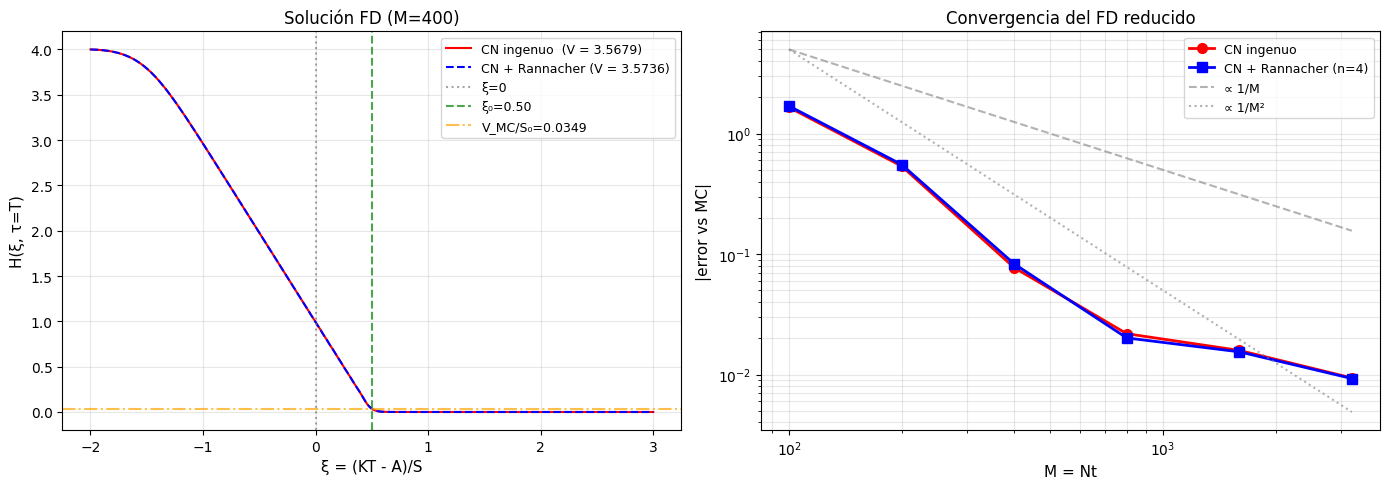

In [35]:



def fd_rogers_shi_asian(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                        regime=0, xi_min=-2.0, xi_max=3.0,
                        M=400, Nt=400, theta=0.5, n_rannacher=0):
    """
    FD theta-scheme sobre la PDE reducida de Rogers-Shi.

    Cambio de variable: ξ = (KT - A)/S,   H_i(ξ, t) = V_i(S, A, t)/S
    PDE:  H_t + (σ_i²ξ²/2) H_ξξ - (r_iξ + 1) H_ξ + λ_i (H_{1-i} - H_i) = 0
    Cond. terminal: H_i(ξ, T) = (-ξ)⁺/T
    Cond. asintóticas:
        H_i(ξ_min) = -ξ_min/T  (lineal, deep ITM)
        H_i(ξ_max) = 0          (deep OTM)
    Precio: V_i(S₀, 0, 0) = S₀ · H_i(KT/S₀, 0)

    n_rannacher : pasos iniciales con θ=1 (implícito puro) para amortiguar
                  oscilaciones espurias del kink terminal.
                  n_rannacher = 0 → esquema ingenuo (sin regularización).
    """
    dxi = (xi_max - xi_min) / M
    xi = np.linspace(xi_min, xi_max, M + 1)
    n_int = M - 1
    dtau = T / Nt
    xi_int = xi[1:M]

    def coefs(sigma_i, r_i, lam_i):
        diff_term = 0.5 * sigma_i**2 * xi_int**2 / dxi**2
        adv_term  = (r_i * xi_int + 1.0) / (2.0 * dxi)
        a = diff_term + adv_term
        b = -2.0 * diff_term - lam_i
        c = diff_term - adv_term
        return a, b, c

    a0, b0, c0 = coefs(sigma0, r0, lam0)
    a1, b1, c1 = coefs(sigma1, r1, lam1)

    L0 = diags([a0[1:], b0, c0[:-1]], offsets=[-1, 0, 1],
               shape=(n_int, n_int), format='csr')
    L1 = diags([a1[1:], b1, c1[:-1]], offsets=[-1, 0, 1],
               shape=(n_int, n_int), format='csr')
    Iblock = identity(n_int, format='csr')
    L = bmat([[L0, lam0 * Iblock], [lam1 * Iblock, L1]], format='csr')

    H_init = np.maximum(-xi_int, 0.0) / T
    U = np.concatenate([H_init, H_init])

    H_left = -xi_min / T
    H_right = 0.0
    ghost0 = np.zeros(n_int); ghost0[0] = a0[0]*H_left; ghost0[-1] = c0[-1]*H_right
    ghost1 = np.zeros(n_int); ghost1[0] = a1[0]*H_left; ghost1[-1] = c1[-1]*H_right
    ghost = np.concatenate([ghost0, ghost1])

    I2 = identity(2 * n_int, format='csr')
    lu_full     = splu((I2 - 1.0 * dtau * L).tocsc())
    lu_theta    = splu((I2 - theta * dtau * L).tocsc())
    B_exp_theta = (I2 + (1.0 - theta) * dtau * L).tocsr()

    for n in range(Nt):
        if n < n_rannacher:
            U = lu_full.solve(U + dtau * ghost)
        else:
            U = lu_theta.solve(B_exp_theta @ U + dtau * ghost)

    xi0 = K * T / S0
    H_grid = U[:n_int] if regime == 0 else U[n_int:]
    H_xi0 = np.interp(xi0, xi_int, H_grid)
    precio = S0 * H_xi0

    H_full = np.concatenate([[H_left], H_grid, [H_right]])
    return float(precio), xi, H_full


# =============================================================
# Experimento: caso C, régimen 0
# =============================================================
S0, K, T = 100.0, 100.0, 0.5
r0, r1 = 0.02, 0.06
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0
V_mc = 3.4907   # referencia MC del Ej. 11 (régimen 0, caso C)

print("=" * 82)
print("EJERCICIO 15 — FD 1D sobre Rogers-Shi (diagnóstico)")
print("=" * 82)
print(f"Parámetros (caso C): S0={S0}, K={K}, T={T}")
print(f"                     r=({r0},{r1}), σ=({sigma0},{sigma1}), "
      f"λ=({lam0},{lam1})")
print(f"Referencia MC (Ej. 11, régimen 0): V_MC = {V_mc:.4f}")
print(f"ξ₀ = KT/S₀ = {K*T/S0:.2f} (lado OTM: payoff terminal vale 0)")

# ---------------------------------------------------------------------
# PARTE (a) — Diagnóstico SIN regularización
# ---------------------------------------------------------------------
print("\n" + "=" * 82)
print("PARTE (a) — FD ingenuo (Crank-Nicolson sin regularización)")
print("=" * 82)

# (a.1) Convergencia con M = Nt
print(f"\n(a.1) Convergencia con M = Nt (dominio ξ ∈ [-2, 3])")
print(f"{'M = Nt':>8} | {'Precio FD':>11} | {'|err vs MC|':>12} | "
      f"{'razón':>8}")
print("-" * 60)
prev_err = None
for M_val in [100, 200, 400, 800, 1600]:
    p, _, _ = fd_rogers_shi_asian(
        S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=0, M=M_val, Nt=M_val, theta=0.5, n_rannacher=0
    )
    err = abs(p - V_mc)
    ratio = (prev_err / err) if (prev_err and err > 0) else float('nan')
    ratio_str = f"{ratio:.2f}×" if np.isfinite(ratio) else "  —"
    print(f"{M_val:>8} | {p:>11.4f} | {err:>12.4f} | {ratio_str:>8}")
    prev_err = err

# (a.2) Refinamiento asimétrico
print(f"\n(a.2) Refinamiento asimétrico — confirma patología espacial")
print(f"{'M':>6} {'Nt':>6} | {'Precio':>10} | {'|err|':>10}")
print("-" * 50)
print("  Refinar SOLO en espacio (Nt=100 fijo):")
for M_val in [100, 200, 400, 800]:
    p, _, _ = fd_rogers_shi_asian(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                                   regime=0, M=M_val, Nt=100, theta=0.5)
    print(f"{M_val:>6} {100:>6} | {p:>10.4f} | {abs(p-V_mc):>10.4f}")
print("  Refinar SOLO en tiempo (M=100 fijo):")
for Nt_val in [100, 200, 400, 800]:
    p, _, _ = fd_rogers_shi_asian(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                                   regime=0, M=100, Nt=Nt_val, theta=0.5)
    print(f"{100:>6} {Nt_val:>6} | {p:>10.4f} | {abs(p-V_mc):>10.4f}")

# (a.3) Dependencia del dominio
print(f"\n(a.3) Dependencia del dominio (M=Nt=400, θ=0.5)")
print(f"{'ξ_min':>6} {'ξ_max':>6} | {'Precio':>10} | {'|err|':>10}")
print("-" * 50)
for xi_lo, xi_hi in [(-2, 3), (-5, 3), (-10, 3), (-2, 5), (-5, 5)]:
    p, _, _ = fd_rogers_shi_asian(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                                   regime=0, xi_min=xi_lo, xi_max=xi_hi,
                                   M=400, Nt=400, theta=0.5)
    print(f"{xi_lo:>6} {xi_hi:>6} | {p:>10.4f} | {abs(p-V_mc):>10.4f}")

print("\nDiagnóstico Parte (a):")
print("  • El kink en ξ=0 hace que la convergencia no sea limpia.")
print("  • Refinar solo el tiempo casi no ayuda; el error principal es espacial.")
print("  • Refinar el espacio sí mejora el precio, pero el resultado depende")
print("    bastante del dominio elegido para ξ.")
print("  • Conclusión: el FD reducido puede funcionar, pero es sensible a la")
print("    malla y a las fronteras. Por eso MC es una referencia más robusta.")

# ---------------------------------------------------------------------
# PARTE (b) — Rannacher smoothing
# ---------------------------------------------------------------------
print("\n" + "=" * 82)
print("PARTE (b) — Rannacher smoothing (primeros 2-4 pasos implícitos)")
print("=" * 82)
print(f"\n{'M = Nt':>6} | {'n_rann':>6} | {'Precio':>10} | {'|err|':>10}")
print("-" * 50)
for M_val in [100, 400, 1600]:
    for n_rann in [0, 2, 4]:
        p, _, _ = fd_rogers_shi_asian(
            S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
            regime=0, M=M_val, Nt=M_val, theta=0.5, n_rannacher=n_rann
        )
        marker = " (ingenuo)" if n_rann == 0 else ""
        print(f"{M_val:>6} | {n_rann:>6} | {p:>10.4f} | "
              f"{abs(p-V_mc):>10.4f}{marker}")
    print()

print("Conclusión Parte (b):")
print("  Rannacher cambia poco los precios en este ejemplo.")
print("  Ayuda a suavizar el kink, pero no corrige el problema principal:")
print("  la degeneración del difusor en ξ=0 y la sensibilidad al dominio.")
print("  Para mejorar más habría que usar una transformación tipo Vecer")
print("  o una malla no uniforme concentrada cerca de ξ=0.")

print("\n" + "=" * 82)
print("MENSAJE FINAL DEL EJERCICIO:")
print("=" * 82)
print("  • El FD reducido se acerca a MC cuando se refina bastante la malla.")
print("  • Aun así, es sensible al dominio y requiere más cuidado numérico.")
print("  • MC es más simple y estable para esta asiática aritmética.")

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

M_plot = 400
p_naive, xi_grid, H_naive = fd_rogers_shi_asian(
    S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
    regime=0, M=M_plot, Nt=M_plot, theta=0.5, n_rannacher=0
)
p_rann, _, H_rann = fd_rogers_shi_asian(
    S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
    regime=0, M=M_plot, Nt=M_plot, theta=0.5, n_rannacher=4
)

ax = axes[0]
ax.plot(xi_grid, H_naive, 'r-', linewidth=1.5,
        label=f'CN ingenuo  (V = {p_naive:.4f})')
ax.plot(xi_grid, H_rann,  'b--', linewidth=1.5,
        label=f'CN + Rannacher (V = {p_rann:.4f})')
ax.axvline(0, color='gray', linestyle=':', alpha=0.7, label='ξ=0')
ax.axvline(K*T/S0, color='green', linestyle='--', alpha=0.7,
           label=f'ξ₀={K*T/S0:.2f}')
ax.axhline(V_mc/S0, color='orange', linestyle='-.', alpha=0.7,
           label=f'V_MC/S₀={V_mc/S0:.4f}')
ax.set_xlabel('ξ = (KT - A)/S', fontsize=11)
ax.set_ylabel('H(ξ, τ=T)', fontsize=11)
ax.set_title(f'Solución FD (M={M_plot})', fontsize=12)
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)

ax = axes[1]
Ms_plot = [100, 200, 400, 800, 1600, 3200]
errs_ingenuo = []
errs_rann = []
for M_val in Ms_plot:
    p_n, _, _ = fd_rogers_shi_asian(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                                     regime=0, M=M_val, Nt=M_val,
                                     theta=0.5, n_rannacher=0)
    p_r, _, _ = fd_rogers_shi_asian(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                                     regime=0, M=M_val, Nt=M_val,
                                     theta=0.5, n_rannacher=4)
    errs_ingenuo.append(abs(p_n - V_mc))
    errs_rann.append(abs(p_r - V_mc))

ax.loglog(Ms_plot, errs_ingenuo, 'r-o', linewidth=2,
          label='CN ingenuo', markersize=7)
ax.loglog(Ms_plot, errs_rann, 'b-s', linewidth=2,
          label='CN + Rannacher (n=4)', markersize=7)
M_ref = np.array([100, 3200])
ax.loglog(M_ref, 500/M_ref, '--', color='gray', alpha=0.6, label='∝ 1/M')
ax.loglog(M_ref, 50000/M_ref**2, ':', color='gray', alpha=0.6, label='∝ 1/M²')
ax.set_xlabel('M = Nt', fontsize=11)
ax.set_ylabel('|error vs MC|', fontsize=11)
ax.set_title('Convergencia del FD reducido', fontsize=12)
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

###PUNTO 16

In [36]:


# Parámetros base comunes
S0, K, T = 100.0, 100.0, 0.5
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0

# Configuración numérica (según enunciado §6.1)
M_fd, Nt_fd       = 300, 300
M_psor, Nt_psor   = 300, 300
n_paths, n_steps  = 200_000, 200
omega_psor        = 1.2
tol_psor          = 1e-7
maxit_psor        = 500
seed              = 42

# Cuatro escenarios de tasas
escenarios = [
    ('A: r0 = r1 = 0.03 (Taller 2)',         0.03, 0.03),
    ('B: r0 = 0.02, r1 = 0.06 (Taller 3)',   0.02, 0.06),
    ('C: r0 = 0.01, r1 = 0.08 (spread amplio)', 0.01, 0.08),
    ('D: r0 = r1 = 0.05 (referencia alta)',  0.05, 0.05),
]

print("=" * 96)
print("EJERCICIO 16 — Tabla maestra de precios (4 escenarios × 2 regímenes × 3 métodos)")
print("=" * 96)
print(f"Parámetros base: S0={S0}, K={K}, T={T}, σ=({sigma0}, {sigma1}), "
      f"λ=({lam0}, {lam1})")
print(f"Configuración: FD M=Nt={M_fd}  |  PSOR M=Nt={M_psor}  |  "
      f"MC n_paths={n_paths}, n_steps={n_steps}")
print()

# Valores de referencia del enunciado
referencia = {
    'A': {0: (5.2808, 5.3645, 3.5617),  1: (7.3723, 7.5238, 5.6824)},
    'B': {0: (5.3160, 5.4017, 3.5155),  1: (7.1332, 7.2983, 5.8375)},
    'C': {0: (5.4090, 5.4921, 3.4524),  1: (7.0226, 7.1907, 5.9276)},
    'D': {0: (4.8175, 4.9833, 3.8124),  1: (6.8829, 7.1798, 5.9078)},
}

# Encabezado
print(f"{'Escenario':<42} | {'reg':>3} | {'V^eur':>7} | {'V^amer':>7} | "
      f"{'V^asia':>7} | {'Prima Am.':>9}")
print("-" * 96)

resultados = {}
tiempos = {'fd': 0.0, 'psor': 0.0, 'mc': 0.0}
t_total_start = time.perf_counter()

for nombre, r0, r1 in escenarios:
    letra = nombre[0]
    resultados[letra] = {}

    for reg in [0, 1]:
        # 1. FD para put europea
        t0 = time.perf_counter()
        V_eur = fd_european_put_markov(
            S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
            regime=reg, M=M_fd, Nt=Nt_fd, theta=0.5
        )
        tiempos['fd'] += time.perf_counter() - t0

        # 2. PSOR para put americana
        t0 = time.perf_counter()
        V_amer, _, _ = fd_american_put_psor(
            S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
            regime=reg, M=M_psor, Nt=Nt_psor,
            omega=omega_psor, tol=tol_psor, maxit=maxit_psor
        )
        tiempos['psor'] += time.perf_counter() - t0

        # 3. MC para call asiática
        t0 = time.perf_counter()
        V_asia, se_asia, _, _ = mc_asian_markov(
            S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
            regime=reg, n_paths=n_paths, n_steps=n_steps, seed=seed
        )
        tiempos['mc'] += time.perf_counter() - t0

        prima = V_amer - V_eur
        resultados[letra][reg] = (V_eur, V_amer, V_asia, prima, se_asia)

        nombre_print = nombre if reg == 0 else ' ' * len(nombre)
        print(f"{nombre_print:<42} | {reg:>3} | {V_eur:>7.4f} | "
              f"{V_amer:>7.4f} | {V_asia:>7.4f} | {prima:>9.4f}")
    print()

t_total = time.perf_counter() - t_total_start
print(f"Tiempo total: {t_total:.1f}s   (FD: {tiempos['fd']:.1f}s, "
      f"PSOR: {tiempos['psor']:.1f}s, MC: {tiempos['mc']:.1f}s)")

# ---------------------------------------------------------------------
# Verificación contra valores de referencia
# ---------------------------------------------------------------------
print("\n" + "=" * 96)
print("Verificación contra valores de referencia")
print("=" * 96)
print(f"{'Escenario':<42} | {'reg':>3} | {'método':<12} | {'mío':>8} | "
      f"{'ref':>8} | {'|diff|':>7}")
print("-" * 96)

max_diff = {'eur': 0, 'amer': 0, 'asia': 0}
for nombre, _, _ in escenarios:
    letra = nombre[0]
    for reg in [0, 1]:
        Veur_m, Vamer_m, Vasia_m, prima_m, se_asia = resultados[letra][reg]
        Veur_r, Vamer_r, Vasia_r = referencia[letra][reg]

        de = abs(Veur_m - Veur_r);   max_diff['eur']  = max(max_diff['eur'], de)
        da = abs(Vamer_m - Vamer_r); max_diff['amer'] = max(max_diff['amer'], da)
        ds = abs(Vasia_m - Vasia_r); max_diff['asia'] = max(max_diff['asia'], ds)

        nombre_print = nombre if reg == 0 else ' ' * len(nombre)
        print(f"{nombre_print:<42} | {reg:>3} | {'eur (FD)':<12} | "
              f"{Veur_m:>8.4f} | {Veur_r:>8.4f} | {de:>7.4f}")
        print(f"{' ' * 42:<42} | {' ':>3} | {'amer (PSOR)':<12} | "
              f"{Vamer_m:>8.4f} | {Vamer_r:>8.4f} | {da:>7.4f}")
        print(f"{' ' * 42:<42} | {' ':>3} | {'asia (MC)':<12} | "
              f"{Vasia_m:>8.4f} | {Vasia_r:>8.4f} | {ds:>7.4f}  "
              f"(MC SE={se_asia:.4f})")
    print()

print(f"Errores máximos vs referencia:")
print(f"  Europeas (FD):     {max_diff['eur']:.4f}")
print(f"  Americanas (PSOR): {max_diff['amer']:.4f}")
print(f"  Asiáticas (MC):    {max_diff['asia']:.4f}  (ruido MC, varía por semilla)")

# ---------------------------------------------------------------------
# Observaciones cualitativas
# ---------------------------------------------------------------------
print("\n" + "=" * 96)
print("Observaciones cualitativas")
print("=" * 96)

print("\n(1) Régimen 1 (vol alta σ=0.40) es siempre más caro que régimen 0 (vol baja σ=0.15):")
print(f"{'Escenario':<42} | {'V^eur reg 1 / V^eur reg 0':>30}")
for nombre, _, _ in escenarios:
    letra = nombre[0]
    V0 = resultados[letra][0][0]
    V1 = resultados[letra][1][0]
    print(f"{nombre:<42} | {V1/V0:>30.4f}")

print("\n(2) Efecto del spread r_1 - r_0 sobre el régimen 0 (de A→B→C):")
print(f"    A (r0=r1=0.03):       V^eur reg 0 = {resultados['A'][0][0]:.4f}")
print(f"    B (r0=0.02, r1=0.06): V^eur reg 0 = {resultados['B'][0][0]:.4f}  "
      f"(+{resultados['B'][0][0]-resultados['A'][0][0]:.4f})")
print(f"    C (r0=0.01, r1=0.08): V^eur reg 0 = {resultados['C'][0][0]:.4f}  "
      f"(+{resultados['C'][0][0]-resultados['A'][0][0]:.4f})")
print(f"    Tendencia: la put en régimen 0 SUBE con el spread (porque la")
print(f"    posibilidad de saltar al régimen 1 con alta vol la hace más valiosa).")

print("\n(3) Prima americana mayor en régimen 1 que en régimen 0 (todos los escenarios):")
print(f"{'Escenario':<42} | {'Π_0':>8} | {'Π_1':>8} | {'Π_1/Π_0':>9}")
for nombre, _, _ in escenarios:
    letra = nombre[0]
    p0 = resultados[letra][0][3]
    p1 = resultados[letra][1][3]
    print(f"{nombre:<42} | {p0:>8.4f} | {p1:>8.4f} | {p1/p0:>9.2f}×")
print(f"    Confirma la intuición: opcionalidad de ejercicio anticipado")
print(f"    es más valiosa cuando la volatilidad es alta.")

print("\n(4) Asiáticas (call) sistemáticamente más baratas que europeas (put):")
print(f"    El promedio aritmético reduce la varianza efectiva del payoff")
print(f"    (σ_promedio ≈ σ/√3 en BS estándar), abaratando la opción.")

EJERCICIO 16 — Tabla maestra de precios (4 escenarios × 2 regímenes × 3 métodos)
Parámetros base: S0=100.0, K=100.0, T=0.5, σ=(0.15, 0.4), λ=(2.0, 5.0)
Configuración: FD M=Nt=300  |  PSOR M=Nt=300  |  MC n_paths=200000, n_steps=200

Escenario                                  | reg |   V^eur |  V^amer |  V^asia | Prima Am.
------------------------------------------------------------------------------------------------
A: r0 = r1 = 0.03 (Taller 2)               |   0 |  5.2808 |  5.3645 |  3.5468 |    0.0837
                                           |   1 |  7.3723 |  7.5238 |  5.6623 |    0.1515

B: r0 = 0.02, r1 = 0.06 (Taller 3)         |   0 |  5.3160 |  5.4017 |  3.5007 |    0.0857
                                           |   1 |  7.1332 |  7.2983 |  5.8168 |    0.1651

C: r0 = 0.01, r1 = 0.08 (spread amplio)    |   0 |  5.4090 |  5.4921 |  3.4378 |    0.0831
                                           |   1 |  7.0226 |  7.1907 |  5.9067 |    0.1681

D: r0 = r1 = 0.05 (referencia 

###PUNTO 17

EJERCICIO 17 — Sensibilidad al spread de tasas (régimen 0)
Parámetros: S0=100.0, K=100.0, T=0.5, σ=(0.15, 0.4), λ=(2.0, 5.0)
r_0 fijo = 0.02,  r_1 ∈ [0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1]

   r_1 |  spread |           V^eur |          V^amer |           V^asia
       | r_1-r_0 |     mío     ref |     mío     ref |     mío      ref
--------------------------------------------------------------------------------------------
 0.020 |  +0.000 |  5.5248  5.5248 |  5.5722  5.5722 |  3.4257  3.3960
 0.030 |  +0.010 |  5.4717  5.4717 |  5.5276  5.5276 |  3.4443  3.4146
 0.040 |  +0.020 |  5.4192  5.4192 |  5.4844  5.4844 |  3.4630  3.4334
 0.050 |  +0.030 |  5.3673  5.3673 |  5.4425  5.4425 |  3.4818  3.4522
 0.060 |  +0.040 |  5.3160  5.3160 |  5.4017  5.4017 |  3.5007  3.4711
 0.080 |  +0.060 |  5.2151  5.2151 |  5.3233  5.3233 |  3.5388  3.5093
 0.100 |  +0.080 |  5.1164  5.1164 |  5.2486  5.2486 |  3.5772  3.5478

Tiempo total: 21.5s

Verificación de monotonía

(1) V^eur decrece con r_1

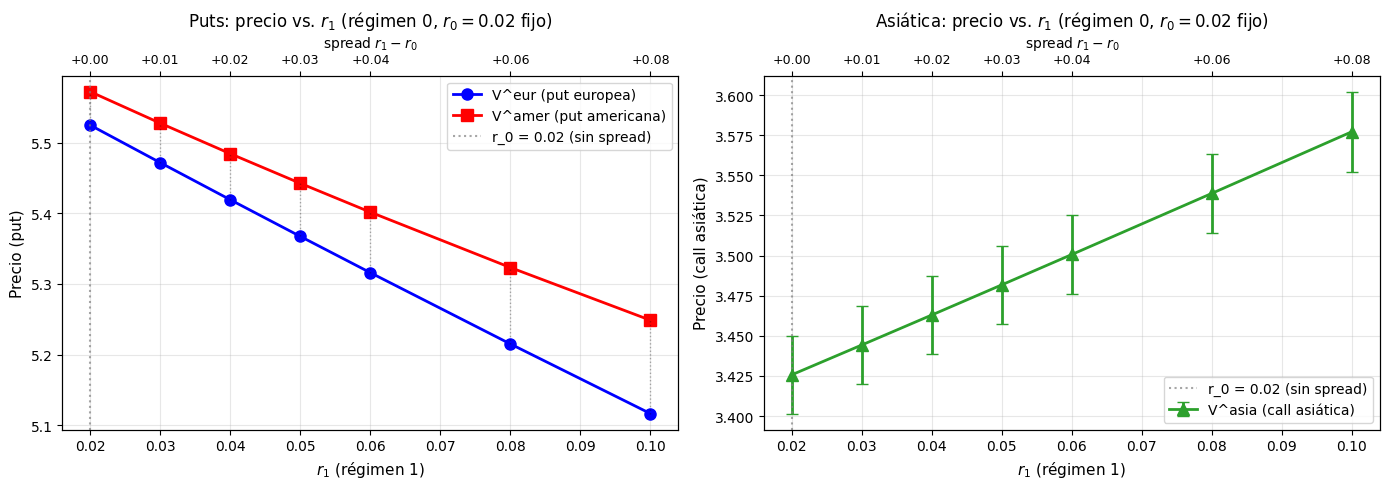


Interpretación financiera:

El efecto de r_1 cambia según el payoff:

- En las puts, subir r_1 baja el precio. La razón principal es que el strike
  se descuenta más fuerte cuando la cadena visita el régimen 1.

- En la call asiática, subir r_1 tiende a subir el precio. La tasa más alta
  aumenta la deriva de S durante las visitas al régimen 1, y eso eleva el
  promedio aritmético.

- La tendencia de la asiática es pequeña frente al error Monte Carlo. Para
  confirmarla con más fuerza conviene usar common random numbers en todos
  los valores de r_1.



In [37]:


# Parámetros base
S0, K, T = 100.0, 100.0, 0.5
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0

# Configuración numérica
M_fd, Nt_fd       = 300, 300
M_psor, Nt_psor   = 300, 300
n_paths, n_steps  = 200_000, 200
seed              = 42

# Valor fijo de r_0 y barrido de r_1
r0_fix = 0.02
r1_vals = [0.020, 0.030, 0.040, 0.050, 0.060, 0.080, 0.100]

# Valores de referencia del enunciado
referencia = {
    0.020: (5.5248, 5.5722, 3.3960),
    0.030: (5.4717, 5.5276, 3.4146),
    0.040: (5.4192, 5.4844, 3.4334),
    0.050: (5.3673, 5.4425, 3.4522),
    0.060: (5.3160, 5.4017, 3.4711),
    0.080: (5.2151, 5.3233, 3.5093),
    0.100: (5.1164, 5.2486, 3.5478),
}

print("=" * 92)
print("EJERCICIO 17 — Sensibilidad al spread de tasas (régimen 0)")
print("=" * 92)
print(f"Parámetros: S0={S0}, K={K}, T={T}, σ=({sigma0}, {sigma1}), "
      f"λ=({lam0}, {lam1})")
print(f"r_0 fijo = {r0_fix},  r_1 ∈ {r1_vals}")
print()

# ---------------------------------------------------------------------
# Cálculo de los precios para cada r_1
# ---------------------------------------------------------------------
print(f"{'r_1':>6} | {'spread':>7} | {'V^eur':>15} | {'V^amer':>15} | "
      f"{'V^asia':>16}")
print(f"{'':>6} | {'r_1-r_0':>7} | {'mío':>7} {'ref':>7} | "
      f"{'mío':>7} {'ref':>7} | {'mío':>7} {'ref':>8}")
print("-" * 92)

resultados = {}
t_start = time.perf_counter()

for r1 in r1_vals:
    spread = r1 - r0_fix

    V_eur = fd_european_put_markov(
        S0, K, T, r0_fix, r1, sigma0, sigma1, lam0, lam1,
        regime=0, M=M_fd, Nt=Nt_fd, theta=0.5
    )
    V_amer, _, _ = fd_american_put_psor(
        S0, K, T, r0_fix, r1, sigma0, sigma1, lam0, lam1,
        regime=0, M=M_psor, Nt=Nt_psor,
        omega=1.2, tol=1e-7, maxit=500
    )
    V_asia, se_asia, _, _ = mc_asian_markov(
        S0, K, T, r0_fix, r1, sigma0, sigma1, lam0, lam1,
        regime=0, n_paths=n_paths, n_steps=n_steps, seed=seed
    )
    resultados[r1] = (V_eur, V_amer, V_asia, se_asia)
    Veur_r, Vamer_r, Vasia_r = referencia[r1]
    print(f"{r1:>6.3f} | {spread:>+7.3f} | "
          f"{V_eur:>7.4f} {Veur_r:>7.4f} | "
          f"{V_amer:>7.4f} {Vamer_r:>7.4f} | "
          f"{V_asia:>7.4f} {Vasia_r:>7.4f}")

t_total = time.perf_counter() - t_start
print(f"\nTiempo total: {t_total:.1f}s")

# ---------------------------------------------------------------------
# Verificación de monotonía
# ---------------------------------------------------------------------
print("\n" + "=" * 92)
print("Verificación de monotonía")
print("=" * 92)

Veur_arr  = np.array([resultados[r1][0] for r1 in r1_vals])
Vamer_arr = np.array([resultados[r1][1] for r1 in r1_vals])
Vasia_arr = np.array([resultados[r1][2] for r1 in r1_vals])

diffs_eur = np.diff(Veur_arr)
mono_eur = np.all(diffs_eur < 0)
print(f"\n(1) V^eur decrece con r_1?  {'OK' if mono_eur else 'FALLA'}")
print(f"    Variación total: {Veur_arr[0]:.4f} → {Veur_arr[-1]:.4f}  "
      f"(Δ = {Veur_arr[-1] - Veur_arr[0]:+.4f})")
print(f"    Sentido: con r_1 ↑, el descuento e^(-r_1·τ) durante visitas")
print(f"    al régimen 1 es más severo → menor valor presente esperado de K.")

diffs_amer = np.diff(Vamer_arr)
mono_amer = np.all(diffs_amer < 0)
print(f"\n(2) V^amer decrece con r_1?  {'OK' if mono_amer else 'FALLA'}")
print(f"    Variación total: {Vamer_arr[0]:.4f} → {Vamer_arr[-1]:.4f}  "
      f"(Δ = {Vamer_arr[-1] - Vamer_arr[0]:+.4f})")
print(f"    Mismo efecto que la europea, amplificado levemente por la")
print(f"    posibilidad de ejercicio anticipado.")

diffs_asia = np.diff(Vasia_arr)
mono_asia = np.all(diffs_asia > 0)
print(f"\n(3) V^asia CRECE con r_1?  {'OK' if mono_asia else 'FALLA'}")
print(f"    Variación total: {Vasia_arr[0]:.4f} → {Vasia_arr[-1]:.4f}  "
      f"(Δ = {Vasia_arr[-1] - Vasia_arr[0]:+.4f})")
print(f"    Sentido OPUESTO porque es CALL: con r_1 ↑, mayor deriva")
print(f"    esperada de S durante visitas al régimen 1 → mayor Ā_T")
print(f"    → mayor payoff (Ā_T - K)⁺.")

print(f"\n(4) Magnitud del efecto del spread (r_1: 0.02 → 0.10, spread 0 → 0.08):")
print(f"    V^eur:  Δ = {Veur_arr[-1] - Veur_arr[0]:+.4f}  "
      f"({100*(Veur_arr[-1] - Veur_arr[0])/Veur_arr[0]:+.2f}%)")
print(f"    V^amer: Δ = {Vamer_arr[-1] - Vamer_arr[0]:+.4f}  "
      f"({100*(Vamer_arr[-1] - Vamer_arr[0])/Vamer_arr[0]:+.2f}%)")
print(f"    V^asia: Δ = {Vasia_arr[-1] - Vasia_arr[0]:+.4f}  "
      f"({100*(Vasia_arr[-1] - Vasia_arr[0])/Vasia_arr[0]:+.2f}%)")

# ---------------------------------------------------------------------
# Gráfica de dos paneles
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r1_arr = np.array(r1_vals)
spreads = r1_arr - r0_fix

# Panel izquierdo: V^eur y V^amer (decrecen)
ax = axes[0]
ax.plot(r1_arr, Veur_arr,  'b-o', linewidth=2, markersize=8,
        label='V^eur (put europea)')
ax.plot(r1_arr, Vamer_arr, 'r-s', linewidth=2, markersize=8,
        label='V^amer (put americana)')
for r1, ve, va in zip(r1_arr, Veur_arr, Vamer_arr):
    ax.plot([r1, r1], [ve, va], 'k:', alpha=0.3, linewidth=1)
ax.axvline(r0_fix, color='gray', linestyle=':', alpha=0.7,
           label=f'r_0 = {r0_fix} (sin spread)')
ax.set_xlabel(r'$r_1$ (régimen 1)', fontsize=11)
ax.set_ylabel('Precio (put)', fontsize=11)
ax.set_title('Puts: precio vs. $r_1$ (régimen 0, $r_0=0.02$ fijo)',
             fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(r1_arr)
ax2.set_xticklabels([f'{s:+.2f}' for s in spreads], fontsize=9)
ax2.set_xlabel('spread $r_1 - r_0$', fontsize=10)

# Panel derecho: V^asia (crece)
ax = axes[1]
se_arr = np.array([resultados[r1][3] for r1 in r1_vals])
ax.errorbar(r1_arr, Vasia_arr, yerr=1.96*se_arr, marker='^',
            color='tab:green', linewidth=2, markersize=8, capsize=4,
            label='V^asia (call asiática)')
ax.axvline(r0_fix, color='gray', linestyle=':', alpha=0.7,
           label=f'r_0 = {r0_fix} (sin spread)')
ax.set_xlabel(r'$r_1$ (régimen 1)', fontsize=11)
ax.set_ylabel('Precio (call asiática)', fontsize=11)
ax.set_title('Asiática: precio vs. $r_1$ (régimen 0, $r_0=0.02$ fijo)',
             fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(r1_arr)
ax2.set_xticklabels([f'{s:+.2f}' for s in spreads], fontsize=9)
ax2.set_xlabel('spread $r_1 - r_0$', fontsize=10)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Mensaje final
# ---------------------------------------------------------------------
print("\n" + "=" * 92)
print("Interpretación financiera:")
print("=" * 92)
print("""
El efecto de r_1 cambia según el payoff:

- En las puts, subir r_1 baja el precio. La razón principal es que el strike
  se descuenta más fuerte cuando la cadena visita el régimen 1.

- En la call asiática, subir r_1 tiende a subir el precio. La tasa más alta
  aumenta la deriva de S durante las visitas al régimen 1, y eso eleva el
  promedio aritmético.

- La tendencia de la asiática es pequeña frente al error Monte Carlo. Para
  confirmarla con más fuerza conviene usar common random numbers en todos
  los valores de r_1.
""")

###PUNTO 18

EJERCICIO 18 — Prima americana por régimen y vencimiento (escenario B)
Parámetros: S0=100.0, K=100.0, σ=(0.15, 0.4), λ=(2.0, 5.0), r=(0.02, 0.06)

     T |           V^eur_0 |          V^amer_0 |      Π_0 |           V^eur_1 |          V^amer_1 |      Π_1 |  Π_1/Π_0
       |     mío     ref |     mío     ref |          |     mío     ref |     mío     ref |          |         
--------------------------------------------------------------------------------------------------------------------------
  0.25 |  3.5587  3.5587 |  3.5897  3.5918 |   0.0310 |  5.7827  5.7827 |  5.8634  5.8666 |   0.0807 |     2.61
  0.50 |  5.3160  5.3160 |  5.4017  5.4017 |   0.0857 |  7.1332  7.1332 |  7.2983  7.2983 |   0.1651 |     1.93
  1.00 |  7.5939  7.5939 |  7.8225  7.8194 |   0.2286 |  8.8547  8.8547 |  9.1932  9.1909 |   0.3385 |     1.48
  2.00 | 10.2235 10.2235 | 10.8115 10.8051 |   0.5880 | 11.0154 11.0154 | 11.7445 11.7392 |   0.7291 |     1.24

Tiempo total: 43.0s

Verificación de las 3 predic

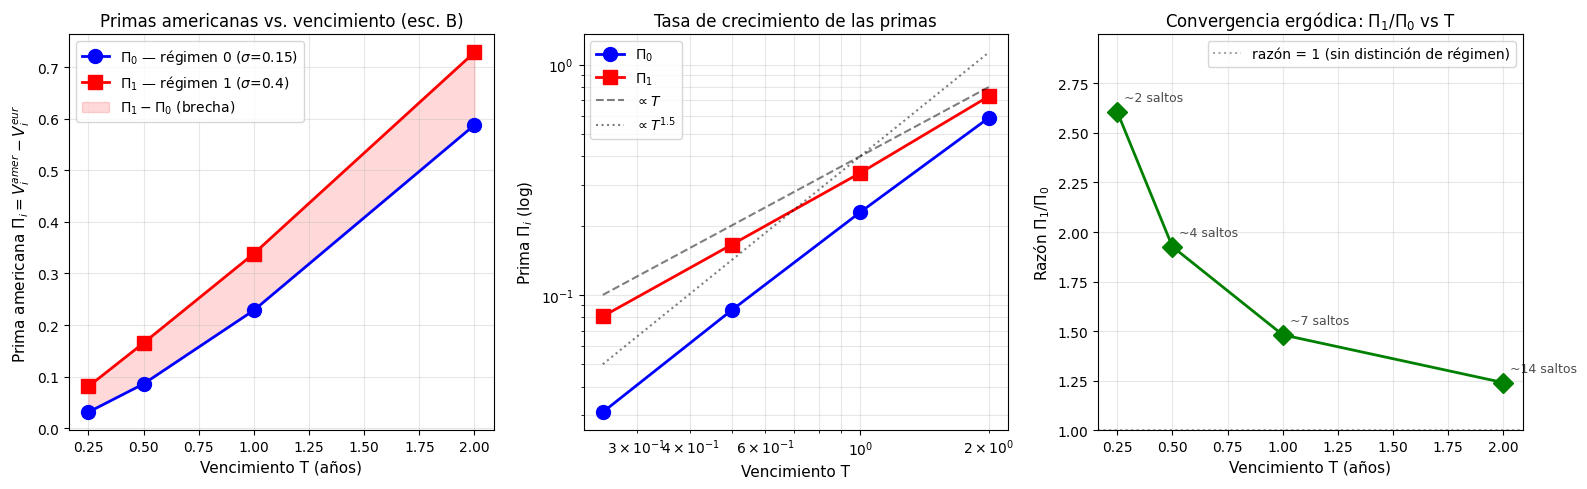


Síntesis e interpretación financiera

La prima americana Π_i mide el valor del derecho de ejercicio anticipado.
En el modelo Markov-modulado depende fuertemente de dos cosas:

  (a) La VOLATILIDAD del régimen actual:
      Π_1 (vol alta, σ=0.40) > Π_0 (vol baja, σ=0.15) siempre,
      porque trayectorias más volátiles ofrecen más oportunidades de
      "pegarle" al ejercicio óptimo.

  (b) El HORIZONTE T:
      A T→0 las primas tienden a 0 (no hay tiempo para ejercer).
      A T grande las primas crecen aproximadamente como T (entre lineal y T^1.5
      según se observa en log-log), porque hay más oportunidades temporales.

La ERGODICIDAD aparece en la razón Π_1/Π_0:
  • A T=0.25 con sólo ~2 saltos esperados, el régimen inicial domina
    completamente → razón = 2.61.
  • A T=2.00 con ~14 saltos esperados, la cadena ha visitado ambos
    regímenes muchas veces → razón = 1.24.

Esta convergencia hacia 1 es la firma cuantitativa de que en el LARGO PLAZO
los precios del modelo Markov-mod

In [38]:

# Parámetros del escenario B
S0, K = 100.0, 100.0
r0, r1 = 0.02, 0.06
sigma0, sigma1 = 0.15, 0.40
lam0, lam1 = 2.0, 5.0

# Configuración numérica
M, Nt_per_year = 300, 600
omega_psor     = 1.2
tol_psor       = 1e-7
maxit_psor     = 500

Ts = [0.25, 0.50, 1.00, 2.00]

# Valores de referencia del enunciado
referencia = {
    0.25: (3.5587, 3.5918, 5.7827, 5.8666),
    0.50: (5.3160, 5.4017, 7.1332, 7.2983),
    1.00: (7.5939, 7.8194, 8.8547, 9.1909),
    2.00: (10.2235, 10.8051, 11.0154, 11.7392),
}

print("=" * 96)
print("EJERCICIO 18 — Prima americana por régimen y vencimiento (escenario B)")
print("=" * 96)
print(f"Parámetros: S0={S0}, K={K}, σ=({sigma0}, {sigma1}), "
      f"λ=({lam0}, {lam1}), r=({r0}, {r1})")
print()

print(f"{'T':>6} | {'V^eur_0':>17} | {'V^amer_0':>17} | {'Π_0':>8} | "
      f"{'V^eur_1':>17} | {'V^amer_1':>17} | {'Π_1':>8} | {'Π_1/Π_0':>8}")
print(f"{'':>6} | {'mío':>7} {'ref':>7} | {'mío':>7} {'ref':>7} | {'':>8} | "
      f"{'mío':>7} {'ref':>7} | {'mío':>7} {'ref':>7} | {'':>8} | {'':>8}")
print("-" * 122)

resultados = {}
t_total_start = time.perf_counter()

for T in Ts:
    Nt = max(int(Nt_per_year * T), 100)

    Veur0 = fd_european_put_markov(
        S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=0, M=M, Nt=Nt, theta=0.5
    )
    Veur1 = fd_european_put_markov(
        S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=1, M=M, Nt=Nt, theta=0.5
    )

    Vamer0, _, _ = fd_american_put_psor(
        S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=0, M=M, Nt=Nt,
        omega=omega_psor, tol=tol_psor, maxit=maxit_psor
    )
    Vamer1, _, _ = fd_american_put_psor(
        S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
        regime=1, M=M, Nt=Nt,
        omega=omega_psor, tol=tol_psor, maxit=maxit_psor
    )

    Pi0 = Vamer0 - Veur0
    Pi1 = Vamer1 - Veur1
    ratio = Pi1 / Pi0

    resultados[T] = (Veur0, Vamer0, Pi0, Veur1, Vamer1, Pi1, ratio)

    Veur0_r, Vamer0_r, Veur1_r, Vamer1_r = referencia[T]
    print(f"{T:>6.2f} | "
          f"{Veur0:>7.4f} {Veur0_r:>7.4f} | {Vamer0:>7.4f} {Vamer0_r:>7.4f} | "
          f"{Pi0:>8.4f} | "
          f"{Veur1:>7.4f} {Veur1_r:>7.4f} | {Vamer1:>7.4f} {Vamer1_r:>7.4f} | "
          f"{Pi1:>8.4f} | {ratio:>8.2f}")

t_total = time.perf_counter() - t_total_start
print(f"\nTiempo total: {t_total:.1f}s")

# ---------------------------------------------------------------------
# Verificación de las 3 predicciones
# ---------------------------------------------------------------------
print("\n" + "=" * 96)
print("Verificación de las 3 predicciones del enunciado")
print("=" * 96)

Pi0_arr = np.array([resultados[T][2] for T in Ts])
Pi1_arr = np.array([resultados[T][5] for T in Ts])
ratio_arr = np.array([resultados[T][6] for T in Ts])

pred1 = np.all(Pi1_arr > Pi0_arr)
print(f"\n(1) Π_1 > Π_0 para todo T?  {'OK' if pred1 else 'FALLA'}")
print(f"    {'T':>6} | {'Π_0':>8} | {'Π_1':>8} | {'Π_1 - Π_0':>10}")
for T, p0, p1 in zip(Ts, Pi0_arr, Pi1_arr):
    print(f"    {T:>6.2f} | {p0:>8.4f} | {p1:>8.4f} | {p1-p0:>10.4f}")
print(f"    Interpretación: el régimen volátil (σ=0.40) ofrece siempre más")
print(f"    opcionalidad de ejercicio anticipado que el estable (σ=0.15).")

dPi0 = np.diff(Pi0_arr)
dPi1 = np.diff(Pi1_arr)
pred2 = np.all(dPi0 > 0) and np.all(dPi1 > 0)
print(f"\n(2) Π_0 y Π_1 crecen monótonamente con T?  {'OK' if pred2 else 'FALLA'}")
print(f"    Π_0: {' → '.join(f'{p:.4f}' for p in Pi0_arr)}")
print(f"    Π_1: {' → '.join(f'{p:.4f}' for p in Pi1_arr)}")
print(f"    Sentido: más tiempo de vida → más oportunidades de que S baje")
print(f"    al rango donde ejercer es óptimo → más valor de la opcionalidad.")

dratio = np.diff(ratio_arr)
pred3 = np.all(dratio < 0)
print(f"\n(3) Π_1 / Π_0 decrece con T?  {'OK' if pred3 else 'FALLA'}")
print(f"    {'T':>6} | {'Π_1/Π_0':>10} | {'saltos esperados':>18}")
for T, r in zip(Ts, ratio_arr):
    n_saltos = (lam0 + lam1) * T
    print(f"    {T:>6.2f} | {r:>10.2f} | {n_saltos:>10.2f} (en avg)")
print(f"    Interpretación ergódica: a horizonte largo la cadena de Markov")
print(f"    explora ambos regímenes muchas veces (~{(lam0+lam1)*2:.0f} saltos a T=2).")
print(f"    El régimen INICIAL se 'olvida' y los precios convergen al del")
print(f"    modelo promedio ponderado por la distribución estacionaria.")
print(f"    Las primas también convergen, así que Π_1/Π_0 → 1 (asintóticamente).")

# ---------------------------------------------------------------------
# Gráfica de 3 paneles
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

Ts_arr = np.array(Ts)

# Panel 1: Π_0 y Π_1 vs T (escala lineal)
ax = axes[0]
ax.plot(Ts_arr, Pi0_arr, 'b-o', linewidth=2, markersize=10,
        label=fr'$\Pi_0$ — régimen 0 ($\sigma$={sigma0})')
ax.plot(Ts_arr, Pi1_arr, 'r-s', linewidth=2, markersize=10,
        label=fr'$\Pi_1$ — régimen 1 ($\sigma$={sigma1})')
ax.fill_between(Ts_arr, Pi0_arr, Pi1_arr, alpha=0.15, color='red',
                label=fr'$\Pi_1 - \Pi_0$ (brecha)')
ax.set_xlabel('Vencimiento T (años)', fontsize=11)
ax.set_ylabel('Prima americana $\\Pi_i = V^{amer}_i - V^{eur}_i$',
              fontsize=11)
ax.set_title('Primas americanas vs. vencimiento (esc. B)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

# Panel 2: log-log
ax = axes[1]
ax.loglog(Ts_arr, Pi0_arr, 'b-o', linewidth=2, markersize=10,
          label=fr'$\Pi_0$')
ax.loglog(Ts_arr, Pi1_arr, 'r-s', linewidth=2, markersize=10,
          label=fr'$\Pi_1$')
ax.loglog(Ts_arr, 0.4*Ts_arr, 'k--', alpha=0.5, label=r'$\propto T$')
ax.loglog(Ts_arr, 0.4*Ts_arr**1.5, 'k:', alpha=0.5, label=r'$\propto T^{1.5}$')
ax.set_xlabel('Vencimiento T', fontsize=11)
ax.set_ylabel('Prima $\\Pi_i$ (log)', fontsize=11)
ax.set_title('Tasa de crecimiento de las primas', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, which='both', alpha=0.3)

# Panel 3: razón Π_1/Π_0 vs T
ax = axes[2]
ax.plot(Ts_arr, ratio_arr, 'g-D', linewidth=2, markersize=10)
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.7,
           label='razón = 1 (sin distinción de régimen)')
for T, r in zip(Ts_arr, ratio_arr):
    n = (lam0 + lam1) * T
    ax.annotate(f'~{n:.0f} saltos', xy=(T, r), xytext=(5, 8),
                textcoords='offset points', fontsize=9, alpha=0.7)
ax.set_xlabel('Vencimiento T (años)', fontsize=11)
ax.set_ylabel('Razón $\\Pi_1 / \\Pi_0$', fontsize=11)
ax.set_title('Convergencia ergódica: $\\Pi_1/\\Pi_0$ vs T', fontsize=12)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim([1.0, max(ratio_arr) * 1.15])

plt.tight_layout()
plt.show()

# Síntesis
print("\n" + "=" * 96)
print("Síntesis e interpretación financiera")
print("=" * 96)
print(f"""
La prima americana Π_i mide el valor del derecho de ejercicio anticipado.
En el modelo Markov-modulado depende fuertemente de dos cosas:

  (a) La VOLATILIDAD del régimen actual:
      Π_1 (vol alta, σ=0.40) > Π_0 (vol baja, σ=0.15) siempre,
      porque trayectorias más volátiles ofrecen más oportunidades de
      "pegarle" al ejercicio óptimo.

  (b) El HORIZONTE T:
      A T→0 las primas tienden a 0 (no hay tiempo para ejercer).
      A T grande las primas crecen aproximadamente como T (entre lineal y T^1.5
      según se observa en log-log), porque hay más oportunidades temporales.

La ERGODICIDAD aparece en la razón Π_1/Π_0:
  • A T=0.25 con sólo ~2 saltos esperados, el régimen inicial domina
    completamente → razón = {ratio_arr[0]:.2f}.
  • A T=2.00 con ~14 saltos esperados, la cadena ha visitado ambos
    regímenes muchas veces → razón = {ratio_arr[-1]:.2f}.

Esta convergencia hacia 1 es la firma cuantitativa de que en el LARGO PLAZO
los precios del modelo Markov-modulado convergen al precio del MODELO
PROMEDIO ponderado por la distribución estacionaria π_0 = {lam1/(lam0+lam1):.4f},
π_1 = {lam0/(lam0+lam1):.4f}. El régimen inicial deja de importar.
""")

### PUNTO 19

**Diseño de un sistema de valoración**

La mesa tiene tres grupos de productos. Usaría un método distinto para cada uno:

1. **Europeas vainilla (70%)**  
   Usaría COS/FFT cuando `r0 = r1`, porque es muy rápido. Si `r0 != r1`, usaría diferencias finitas con Crank-Nicolson. Para vencimientos cortos basta una malla moderada, por ejemplo `M = Nt = 300` o `400`, buscando error menor a 1 centavo.

2. **Americanas vainilla (20%)**  
   Usaría PSOR sobre la PDE acoplada. Es más costoso que FD europeo, pero maneja bien el ejercicio temprano. Para tolerancia de 1 centavo empezaría con `M = Nt = 400` y refinaría solo si la opción está cerca de la frontera de ejercicio.

3. **Asiáticas largas (10%)**  
   Usaría Monte Carlo vectorizado. La opción depende de la trayectoria y el promedio aritmético agrega una variable de estado. Para tolerancia de 5 centavos usaría entre `200,000` y `500,000` paths, con pasos temporales suficientes para el promedio. También usaría common random numbers si se comparan escenarios.

**Precomputaciones útiles**

- En FD europeo, la matriz `L` y la factorización LU se pueden reutilizar para opciones con mismos parámetros de mercado, malla y vencimiento.
- En PSOR, se reutilizan coeficientes `a`, `b`, `c`, payoff y malla.
- En Monte Carlo, se pueden reutilizar semillas o números aleatorios comunes para comparar strikes, vencimientos o spreads de tasas.
- Para chooser y forward start, conviene precomputar tablas de calls/puts europeas por régimen y por `S`.

### PUNTO 20

**Preguntas conceptuales**

1. **Acoplamiento por régimen**  
   La PDE queda acoplada porque el régimen puede cambiar antes del vencimiento. Si hoy estoy en el régimen `i`, mañana puedo estar en `1-i`, y por eso aparece el término `lambda_i (V_{1-i} - V_i)`. En el Taller 2, con `r0 = r1`, la función característica permitía separar mejor el problema.

2. **Por qué falla la factorización del descuento**  
   Si `r0 != r1`, el descuento depende de toda la trayectoria de la cadena. Entonces `exp(-∫ r_e(s) ds)` no sale de la esperanza. Por eso COS/FFT ya no son suficientes para valorar directamente y usamos PDE o Monte Carlo. La frontera `S = 0` muestra el mismo problema: incluso ahí el descuento queda acoplado entre regímenes.

3. **Término de acoplamiento**  
   El término `lambda_i (V_{1-i} - V_i)` mide el cambio esperado de valor si el mercado salta de régimen. Si `V_{1-i} > V_i`, el salto aumenta el precio. Si `V_{1-i} < V_i`, lo reduce.

4. **Ventaja de Putzer**  
   Putzer da una fórmula cerrada para `exp(t C)` en matrices `2 x 2`. Es fácil de programar y evita llamar a una exponencial matricial muchas veces. La limitación es que para `n >= 3` la fórmula ya no es tan simple; ahí conviene usar descomposición espectral o `scipy.linalg.expm`.

5. **Por qué Rogers-Shi funciona con régimen**  
   La reducción funciona porque el acoplamiento es lineal. Si `V_i = S H_i`, entonces `lambda_i(V_{1-i} - V_i)` también tiene un factor `S` común y se simplifica. Si el acoplamiento fuera no lineal, por ejemplo `V_i V_{1-i}`, la reducción ya no cerraría igual.

6. **PDE vs Monte Carlo**  
   FD es muy bueno para opciones vainilla, donde el estado principal es `S`. Monte Carlo es mejor cuando el payoff depende de la trayectoria, como en asiáticas, porque evita resolver una PDE de mayor dimensión. En Rogers-Shi, además, hay un kink y una degeneración cerca de `xi = 0`, lo que hace el FD más delicado.

7. **Mezcla de regímenes**  
   La matriz generadora tiene autovalores `0` y `-(lambda0 + lambda1)`. Por eso la escala de mezcla es
   `tau_mix = 1 / (lambda0 + lambda1) = 1 / 7 ≈ 0.143` años. Para horizontes varias veces mayores que `0.143`, el régimen inicial pesa menos y los precios de ambos regímenes se acercan.

8. **Generalización a más regímenes**  
   FD y PSOR se generalizan de forma directa: la matriz por bloques pasa de `2M x 2M` a `nM x nM`. Monte Carlo también se generaliza simulando una cadena con más estados. Lo más difícil es el método integral de Zheng-Zhu, porque la matriz `C(eta)` es más grande y el tratamiento espectral deja de ser tan simple. Rogers-Shi sigue funcionando mientras el acoplamiento entre regímenes sea lineal.